# 1. Введение

## Dota 2. Предсказание победы Radiant

В этом pet-проекте решается задача бинарной классификации. Требуется предсказать вероятность победы команды **Radiant** на основе характеристик матча, доступных на фиксированный момент времени. Данные включают подготовленные табличные признаки из csv и опциональные сырые данные из jsonl, содержащие логи событий и временные ряды.

**Целевая переменная:** `radiant_win`  
**Формат ответа модели:** вероятность в диапазоне `[0, 1]`

Для оценки качества используется метрика **ROC-AUC**, так как она отражает способность модели разделять победы и поражения на разных порогах классификации и является устойчивой метрикой для задач вероятностного предсказания.

## План работы в ноутбуке

1. Загрузка данных и обзор доступных файлов  
2. Описание структуры признаков и первичный EDA  
3. Предобработка данных  
4. Feature engineering  
5. Построение моделей-бейзлайнов  
6. Корректная кросс-валидация без утечек  
7. Подбор гиперпараметров для лучшей модели  
8. Интерпретация важности признаков  
9. Анализ ошибок и предложения по улучшению  
10. Итоговые выводы и практическая интерпретация результата

## Цель проекта

Построить воспроизводимый пайплайн и получить модель с ROC-AUC существенно выше базового уровня случайного угадывания **0.5**, а также показать, какие игровые факторы вносят наибольший вклад в прогноз исхода.


Участники:
- Матевосов Павел (50%): Обучение и сравнение моделей, подбор гиперпараметров, feature engineering.
- Ефремова Юлия (50%): EDA, подготовка визуализаций, интерпретация, выводы. 

# 2. Окружение и воспроизводимость

In [ ]:
# !pip install catboost==1.2.8
# !pip install optuna==4.6.0
# !pip install scikit-learn==1.7.2
# !pip install pandas==2.3.3
# !pip install numpy==2.2.6
# !pip install ipywidgets==8.1.5

In [3]:
import ast
import random

import catboost
import ipywidgets as widgets
import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import sklearn
from catboost import CatBoostClassifier
from IPython.display import clear_output, display
from matplotlib.lines import Line2D
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

pd.set_option("display.max_columns", None)


RANDOM_STATE = 42

In [4]:
print("pandas:", pd.__version__)
print("numpy:", np.__version__)
print("sklearn:", sklearn.__version__)
print("catboost:", catboost.__version__)
print("ipywidgets:", widgets.__version__)
print("optuna:", optuna.__version__)


pandas: 2.3.3
numpy: 2.2.6
sklearn: 1.7.2
catboost: 1.2.8
ipywidgets: 8.1.5
optuna: 4.6.0


В этом проекте мы стремимся обеспечить воспроизводимость результатов. Ноутбук запускается последовательно с нуля, без скрытых локальных зависимостей. Все используемые данные загружаются из предоставленных файлов проекта. Файлы должны быть помещены в ту же папку что и данный ноутбук. JSONL фйлы также в папке DOTA 2 как и были предоставлены изначально.
Версии ключевых библиотек зафиксированы ниже.


| Библиотека | Версия |
|---|---|
| pandas | 2.3.3 |
| numpy | 2.2.6 |
| scikit-learn | 1.7.2 |
| catboost | 1.2.8 |
| ipywidgets | 8.1.5 |
| optuna | 4.6.0 |



Был использован python версии 3.12.4

In [3]:
train_features_path = "train_features.csv"
train_targets_path = "train_targets.csv"
train_jsonl_path = "DOTA 2/train_matches.jsonl"
test_jsonl_path = "DOTA 2/test_matches.jsonl"

# 3. Загрузка данных

### Основные данные

In [4]:
raw_features = pd.read_csv(train_features_path)
raw_targets = pd.read_csv(train_targets_path)

Для удобства в дальнейшем прикрепим наш таргет к основной табличке с фичами.

In [5]:
raw_features = raw_features.merge(
    raw_targets[["match_id_hash", "radiant_win"]],
    on="match_id_hash",
    how="inner"
)

raw_features.shape

(39675, 247)

In [6]:
raw_features.head()

,match_id_hash,game_time,game_mode,lobby_type,objectives_len,chat_len,r1_hero_id,r1_kills,r1_deaths,r1_assists,r1_denies,r1_gold,r1_lh,r1_xp,r1_health,r1_max_health,r1_max_mana,r1_level,r1_x,r1_y,r1_stuns,r1_creeps_stacked,r1_camps_stacked,r1_rune_pickups,r1_firstblood_claimed,r1_teamfight_participation,r1_towers_killed,r1_roshans_killed,r1_obs_placed,r1_sen_placed,r2_hero_id,r2_kills,r2_deaths,r2_assists,r2_denies,r2_gold,r2_lh,r2_xp,r2_health,r2_max_health,r2_max_mana,r2_level,r2_x,r2_y,r2_stuns,r2_creeps_stacked,r2_camps_stacked,r2_rune_pickups,r2_firstblood_claimed,r2_teamfight_participation,r2_towers_killed,r2_roshans_killed,r2_obs_placed,r2_sen_placed,r3_hero_id,r3_kills,r3_deaths,r3_assists,r3_denies,r3_gold,r3_lh,r3_xp,r3_health,r3_max_health,r3_max_mana,r3_level,r3_x,r3_y,r3_stuns,r3_creeps_stacked,r3_camps_stacked,r3_rune_pickups,r3_firstblood_claimed,r3_teamfight_participation,r3_towers_killed,r3_roshans_killed,r3_obs_placed,r3_sen_placed,r4_hero_id,r4_kills,r4_deaths,r4_assists,r4_denies,r4_gold,r4_lh,r4_xp,r4_health,r4_max_health,r4_max_mana,r4_level,r4_x,r4_y,r4_stuns,r4_creeps_stacked,r4_camps_stacked,r4_rune_pickups,r4_firstblood_claimed,r4_teamfight_participation,r4_towers_killed,r4_roshans_killed,r4_obs_placed,r4_sen_placed,r5_hero_id,r5_kills,r5_deaths,r5_assists,r5_denies,r5_gold,r5_lh,r5_xp,r5_health,r5_max_health,r5_max_mana,r5_level,r5_x,r5_y,r5_stuns,r5_creeps_stacked,r5_camps_stacked,r5_rune_pickups,r5_firstblood_claimed,r5_teamfight_participation,r5_towers_killed,r5_roshans_killed,r5_obs_placed,r5_sen_placed,d1_hero_id,d1_kills,d1_deaths,d1_assists,d1_denies,d1_gold,d1_lh,d1_xp,d1_health,d1_max_health,d1_max_mana,d1_level,d1_x,d1_y,d1_stuns,d1_creeps_stacked,d1_camps_stacked,d1_rune_pickups,d1_firstblood_claimed,d1_teamfight_participation,d1_towers_killed,d1_roshans_killed,d1_obs_placed,d1_sen_placed,d2_hero_id,d2_kills,d2_deaths,d2_assists,d2_denies,d2_gold,d2_lh,d2_xp,d2_health,d2_max_health,d2_max_mana,d2_level,d2_x,d2_y,d2_stuns,d2_creeps_stacked,d2_camps_stacked,d2_rune_pickups,d2_firstblood_claimed,d2_teamfight_participation,d2_towers_killed,d2_roshans_killed,d2_obs_placed,d2_sen_placed,d3_hero_id,d3_kills,d3_deaths,d3_assists,d3_denies,d3_gold,d3_lh,d3_xp,d3_health,d3_max_health,d3_max_mana,d3_level,d3_x,d3_y,d3_stuns,d3_creeps_stacked,d3_camps_stacked,d3_rune_pickups,d3_firstblood_claimed,d3_teamfight_participation,d3_towers_killed,d3_roshans_killed,d3_obs_placed,d3_sen_placed,d4_hero_id,d4_kills,d4_deaths,d4_assists,d4_denies,d4_gold,d4_lh,d4_xp,d4_health,d4_max_health,d4_max_mana,d4_level,d4_x,d4_y,d4_stuns,d4_creeps_stacked,d4_camps_stacked,d4_rune_pickups,d4_firstblood_claimed,d4_teamfight_participation,d4_towers_killed,d4_roshans_killed,d4_obs_placed,d4_sen_placed,d5_hero_id,d5_kills,d5_deaths,d5_assists,d5_denies,d5_gold,d5_lh,d5_xp,d5_health,d5_max_health,d5_max_mana,d5_level,d5_x,d5_y,d5_stuns,d5_creeps_stacked,d5_camps_stacked,d5_rune_pickups,d5_firstblood_claimed,d5_teamfight_participation,d5_towers_killed,d5_roshans_killed,d5_obs_placed,d5_sen_placed,radiant_win
0,a400b8f29dece5f4d266f49f1ae2e98a,155,22,7,1,11,11,0,0,0,0,543,7,533,358,600,350.93784,2,116,122,0.000000,0,0,1,0,0.000000,0,0,0,0,78,0,0,0,3,399,4,478,636,720,254.93774,2,124,126,0.000000,0,0,0,0,0.000000,0,0,0,0,14,0,1,0,0,304,0,130,700,700,242.93773,1,70,156,0.000000,0,0,1,0,0.000000,0,0,0,0,59,0,0,0,1,389,4,506,399,700,326.93780,2,170,86,0.000000,0,0,0,0,0.000000,0,0,0,0,77,0,0,0,0,402,10,344,422,800,314.93780,2,120,100,0.000000,0,0,0,0,0.000000,0,0,0,0,12,0,0,1,13,982,12,780,650,720,386.93787,3,82,170,0.000000,0,0,1,0,1.00,0,0,0,0,21,0,0,0,6,788,9,706,640,640,422.93790,3,174,90,0.000000,0,0,2,0,0.00,0,0,0,0,60,0,0,0,1,531,0,307,720,720,242.93773,2,180,84,0.299948,0,0,2,0,0.00,0,0,0,0,84,1,0,0,0,796,0,421,760,760,326.93780,2,90,150,0.000000,0,0,2,1,1.0,0,0,1,0,34,0,0,0,0,851,11,870,593,680,566.93805,3,128,128,0.000000,0,0,0,0,0.00,0,0,0,0,False
1,b9c57c450ce74a2af79c9ce96fac144d,658,4,0,3,10,15,7,2,0,7,5257,52,3937,1160

## Описание `raw_features` 

Данные содержат параметры матча и статистику 10 игроков на момент времени `game_time`.

### Префиксы и формат
- `r` - Radiant, `d` - Dire  
- цифра 1-5 - номер игрока  
- пример: `r3_gold` - золото 3-го игрока Radiant

### Общие параметры матча
- `match_id_hash` - идентификатор матча, нужен для соединений, из `X` исключается  
- `game_time` - момент фиксации статистики  
- `game_mode`, `lobby_type` - режим и тип лобби  
- `objectives_len`, `chat_len` - агрегированные признаки событий/чата

### Герои
- `r1_hero_id ... r5_hero_id`, `d1_hero_id ... d5_hero_id` - идентификаторы героев

### Основные числовые признаки игроков
Для каждого игрока доступны:
- боевые показатели: `kills`, `deaths`, `assists`, `stuns`  
- фарм/экономика: `lh`, `denies`, `gold`, `xp`  
- состояние героя: `health`, `max_health`, `max_mana`, `level`  
- позиция на карте в данный момент времени: `x`, `y`  
- другая активность: `creeps_stacked`, `camps_stacked`, `rune_pickups`, `firstblood_claimed`,  
  `teamfight_participation`, `towers_killed`, `roshans_killed`, `obs_placed`, `sen_placed`

### Цель
- `radiant_win` - наш таргет, True если победил Radiant, False если Dire


### Сырые/дополнительные данные 

In [7]:
df_train_matches = pd.read_json(train_jsonl_path, lines=True)
df_test_matches  = pd.read_json(test_jsonl_path, lines=True)

df_json_matches = pd.concat([df_train_matches, df_test_matches], ignore_index=True)


In [8]:
df_json_matches.shape

(39675, 9)

In [9]:
df_json_matches.head()

,game_time,match_id_hash,teamfights,objectives,chat,game_mode,lobby_type,players,targets
0,155,a400b8f29dece5f4d266f49f1ae2e98a,[],"[{'time': 124.203, 'type': 'CHAT_MESSAGE_FIRST...","[{'player_slot': 0, 'time': -13.63, 'text': '?...",22,7,"[{'player_slot': 0, 'hero_id': 11, 'hero_name'...","{'game_time': 155, 'duration': 992, 'time_rema..."
1,658,b9c57c450ce74a2af79c9ce96fac144d,"[{'start': -12.266, 'end': 41.209, 'last_death...","[{'time': 2.701, 'type': 'CHAT_MESSAGE_FIRSTBL...","[{'player_slot': 1, 'time': 39.075, 'text': '*...",4,0,"[{'player_slot': 0, 'hero_id': 15, 'hero_name'...","{'game_time': 658, 'duration': 1154, 'time_rem..."
2,21,6db558535151ea18ca70a6892197db41,[],[],[],23,0,"[{'player_slot': 0, 'hero_id': 101, 'hero_name...","{'game_time': 21, 'duration': 1503, 'time_rema..."
3,576,46a0ddce8f7ed2a8d9bd5edcbb925682,[],"[{'time': 154.262, 'type': 'CHAT_MESSAGE_FIRST...","[{'player_slot': 3, 'time': 8.031, 'text': '=?...",22,7,"[{'player_slot': 0, 'hero_id': 14, 'hero_name'...","{'game_time': 576, 'duration': 1952, 'time_rem..."
4,453,b1b35ff97723d9b7ade1c9c3cf48f770,[],"[{'time': -10.997, 'type': 'CHAT_MESSAGE_FIRST...","[{'player_slot': 128, 'time': -72.858, 'text':...",22,7,"[{'player_slot': 0, 'hero_id': 42, 'hero_name'...","{'game_time': 453, 'duration': 2001, 'time_rem..."


## Сырые данные `train_matches.jsonl` и `test_matches.jsonl`

Сырые данные представлены в формате jsonl, где каждая строка соответствует одному матчу. В отличие от `train_features.csv`, здесь хранится более детализированная информация о событиях, участниках и динамике игры. Эти поля опциональны для использования, но могут дать прирост качества при корректном извлечении признаков.

Ниже кратко описаны основные колонки.

### Общие поля матча

- `match_id_hash`  
  Уникальный идентификатор матча. Основной ключ для соединения с табличными признаками.

- `game_time`  
  Момент времени, на который зафиксирован "срез" игры в сырых данных.

- `game_mode`  
  Режим игры.

- `lobby_type`  
  Тип лобби или формат матча.

### События матча

- `objectives`  
  Список игровых целей и событий на карте. Обычно включает объекты вроде убийств башен, Рошана и других важных действий. Поле полезно для построения агрегатов активности и контроля карты.

- `teamfights`  
  Информация о командных сражениях. Может содержать временные интервалы и статистику участников. Потенциальный источник признаков интенсивности игры и распределения вклада по командам.

- `chat`  
  История сообщений чата.

### Игроки и их подробная статистика

- `players`  
  Список из 10 словарей, по одному на каждого игрока. Это ключевая часть jsonl для расширенного feature engineering.

  Внутри `players` встречаются:
  - базовые числовые признаки, аналогичные csv  
    `kills`, `deaths`, `assists`, `gold`, `lh`, `xp`, `level`, `health`
  - координаты  
    `x`, `y`
  - логи событий  
    поля с суффиксом `_log`, например `purchase_log`, `kills_log`, `buyback_log`
  - временные ряды  
    поля с суффиксом `_t`, например `gold_t`, `xp_t`, `lh_t`, `dn_t`  
    обычно значения идут с шагом 60 секунд

  Эти данные позволяют строить признаки динамики и поведения игрока, например скорость роста золота или количество покупок за раннюю фазу игры.



### Как сырые данные могут быть использованы в проекте

Наиболее типичные направления извлечения признаков:
- динамические признаки из `_t` рядов  
  темп фарма, прирост золота и опыта, ранние преимущества
- командные суммы и разницы  
  расширение стандартных агрегатов из csv более детальными сигналами


# 4. Первичный EDA

### 4.1 Структура данных и группы признаков

Признаки можно логически разделить на:
1) общие параметры матча  
2) признаки по игрокам Radiant  
3) признаки по игрокам Dire  
4) целевая переменная

Ниже я формирую списки колонок для дальнейшего анализа.


In [10]:
cols = raw_features.columns.tolist()

target_col = "radiant_win"
id_col = "match_id_hash"

match_cols = ["game_time", "game_mode", "lobby_type", "objectives_len", "chat_len"]
match_cols = [c for c in match_cols if c in cols]

hero_id_cols = [c for c in cols if c.endswith("_hero_id")]

r_cols = [c for c in cols if c.startswith("r") and c not in [target_col, id_col]]
d_cols = [c for c in cols if c.startswith("d") and c not in [target_col, id_col]]

print("Match cols:", len(match_cols))
print("Hero id cols:", len(hero_id_cols))
print("Radiant player cols:", len(r_cols))
print("Dire player cols:", len(d_cols))


Match cols: 5
Hero id cols: 10
Radiant player cols: 120
Dire player cols: 120


### 4.2 Баланс классов

Проверяю распределение целевой переменной. 
Это важно для интерпретации ROC-AUC и для понимания, нужны ли специальные методы балансировки.


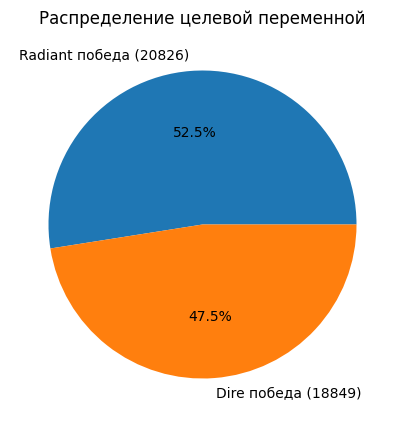

In [11]:
target_col = "radiant_win"

counts = raw_features[target_col].value_counts()

label_map = {
    True: "Radiant победа",
    False: "Dire победа",
    1: "Radiant победа",
    0: "Dire победа",
}

labels = []
values = []
for k, v in counts.items():
    labels.append(f"{label_map.get(k, str(k))} ({v})")
    values.append(v)

plt.figure(figsize=(5, 5))
plt.pie(values, labels=labels, autopct="%1.1f%%")
plt.title("Распределение целевой переменной")
plt.show()



Radiant немного чаше выигрывает. Скорее всего связанно с асимметричностью игровой карты.

### 4.3 Пропуски

Проверяю долю пропусков по колонкам и выделяю потенциально проблемные признаки.


In [12]:
na_rate = raw_features.isna().mean().sort_values(ascending=False)
na_rate.head(5)


match_id_hash     0.0
game_time         0.0
game_mode         0.0
lobby_type        0.0
objectives_len    0.0
dtype: float64

Пропусков нет!

### 4.4 Дубликаты и корректность ключей

Проверяю уникальность `match_id_hash`


In [13]:
raw_features[id_col].duplicated().sum()


np.int64(0)

Дубликатов нет!

### 4.5 Распределения ключевых признаков матча

В этом подпункте я визуализирую распределения наиболее информативных признаков, которые отражают темп и текущее преимущество команд на момент `game_time`.

Для наглядности я рассматриваю:
- контекст матча: `game_time`
- командные агрегаты экономики и темпа: суммарное золото Radiant и Dire
- признаки преимущества: разницы между командами по `gold`, `xp`, `level`, `kills`

Такой набор графиков помогает понять масштаб значений, типичные диапазоны и подтверждает гипотезу, что именно командный перевес по ресурсам и боевой эффективности должен быть важным сигналом для модели.


#### Статистики ключевых признаков

In [14]:
def team_sum(df, prefix, stat):
    cols_stat = [f"{prefix}{i}_{stat}" for i in range(1, 6)]
    cols_stat = [c for c in cols_stat if c in df.columns]
    return df[cols_stat].sum(axis=1)

def build_eda_team_features(df):
    eda = df[["game_time", "radiant_win"]].copy()

    for stat in ["gold", "xp", "level", "kills", "deaths", "assists", "lh", "denies", "stuns"]:
        r_col = f"r1_{stat}"
        d_col = f"d1_{stat}"
        if r_col in df.columns and d_col in df.columns:
            eda[f"r_total_{stat}"] = team_sum(df, "r", stat)
            eda[f"d_total_{stat}"] = team_sum(df, "d", stat)
            eda[f"{stat}_diff"] = eda[f"r_total_{stat}"] - eda[f"d_total_{stat}"]
    return eda


def plot_hist_by_target(
    df,
    col,
    target_col="radiant_win",
    clip_q=(0.01, 0.99),
    bins="fd",
    figsize=(7, 3.5)
):

    tmp = df[[col, target_col]].dropna()


    s = tmp[col]
    if clip_q is not None:
        lo, hi = s.quantile([clip_q[0], clip_q[1]])
        tmp = tmp[(tmp[col] >= lo) & (tmp[col] <= hi)]
        note = f"Показан диапазон {int(clip_q[0]*100)}-{int(clip_q[1]*100)} перцентилей"
    else:
        note = None

    s_r = tmp.loc[tmp[target_col] == 1, col]
    s_d = tmp.loc[tmp[target_col] == 0, col]

    # Бины
    try:
        if bins == "fd":
            edges = np.histogram_bin_edges(tmp[col], bins="fd")
        elif isinstance(bins, int):
            edges = np.histogram_bin_edges(tmp[col], bins=bins)
        else:
            edges = np.histogram_bin_edges(tmp[col], bins="auto")
    except Exception:
        edges = 50

    plt.figure(figsize=figsize)
    plt.hist(s_d, bins=edges, alpha=0.45, label="Dire победа")
    plt.hist(s_r, bins=edges, alpha=0.45, label="Radiant победа")

    plt.title(f"Распределение {col} по исходу матча")
    plt.xlabel(col)
    plt.ylabel("Количество матчей")
    plt.grid(True, alpha=0.2)
    plt.legend()

    if note:
        plt.figtext(0.99, 0.01, note, ha="right", va="bottom", fontsize=8)

    plt.show()


#### Гистограммы ключевых признаков

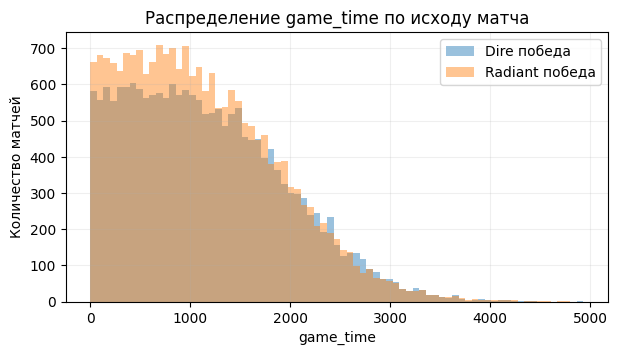

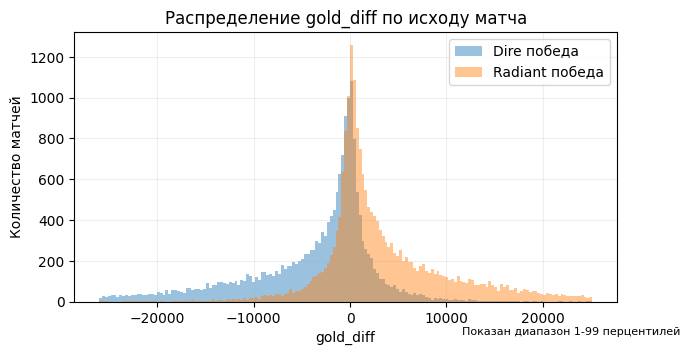

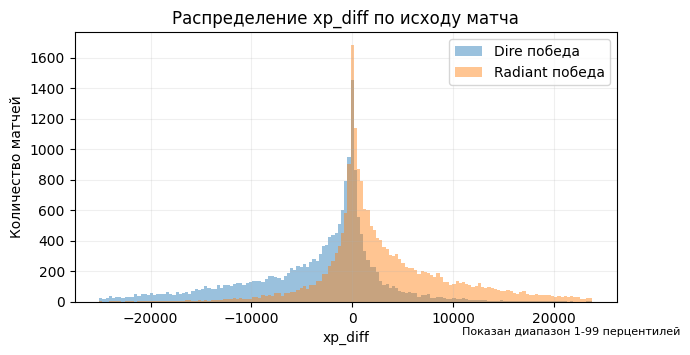

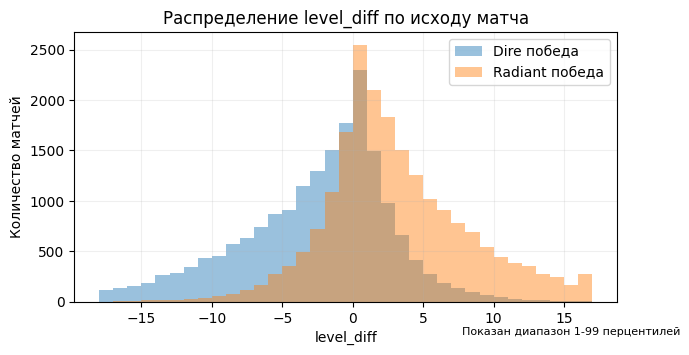

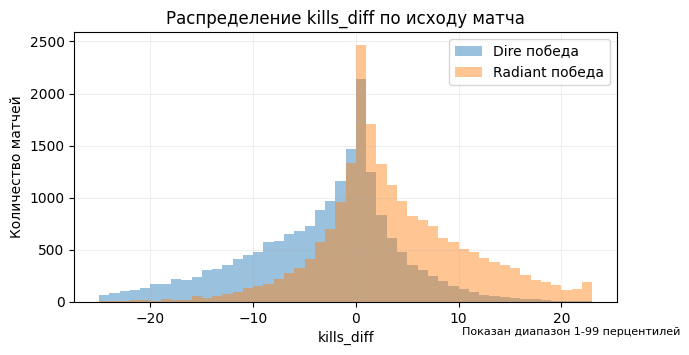

In [15]:
eda_team = build_eda_team_features(raw_features)
plot_hist_by_target(eda_team, "game_time", clip_q=None)

for col in ["gold_diff", "xp_diff", "level_diff", "kills_diff"]:
    if col in eda_team.columns:
        plot_hist_by_target(eda_team, col, clip_q=(0.01, 0.99))


#### Категориальные признаки

Хотя большинство признаков в `raw_features` числовые, в данных есть важные категориальные поля:

1) Матчевые категории
- `game_mode`
- `lobby_type`

2) Категории выбора героев
- `r1_hero_id ... r5_hero_id`
- `d1_hero_id ... d5_hero_id`

Идентификаторы героев несут информацию о композиции команд и ролях, поэтому они являются одними из ключевых категориальных признаков. Они будут учтены в последующих секциях


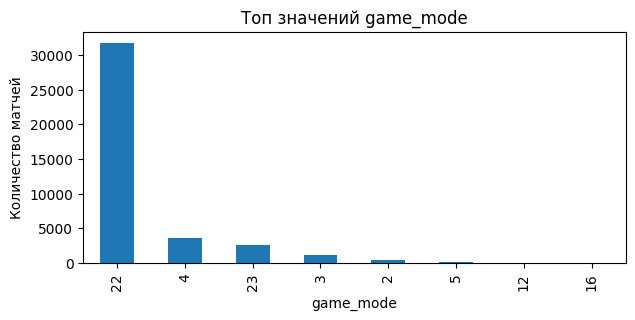

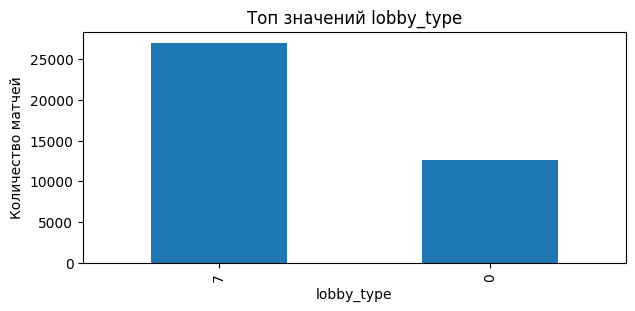

In [16]:
cat_match_cols = [c for c in ["game_mode", "lobby_type"] if c in raw_features.columns]

for col in cat_match_cols:
    vc = raw_features[col].value_counts(dropna=False)

    plt.figure(figsize=(7, 3))
    vc.head(20).plot(kind="bar")
    plt.title(f"Топ значений {col}")
    plt.xlabel(col)
    plt.ylabel("Количество матчей")
    plt.show()



### 4.6 Корреляционный анализ

Корреляции в этом проекте я смотрю выборочно. В Dota 2 важнее не отдельные цифры игроков, а общий перевес команды, поэтому исходные per-player признаки в большой матрице почти не анализирую.

Основной фокус:
- `game_time` как контекст момента среза  
- командные агрегаты и особенно разницы между Radiant и Dire  
  например `gold_diff`, `xp_diff`, `level_diff`, `kills_diff`

Именно такие признаки лучше всего показывают, как текущее преимущество связано с вероятностью победы.

Категориальные признаки вроде `*_hero_id`, `game_mode`, `lobby_type` через корреляции не оцениваю. Для них полезнее частоты и отдельные способы кодирования, включая hero winrate без утечки.

Чтобы визуализация была читаемой, я строю корреляции на компактном наборе из ключевых числовых признаков и командных разниц.

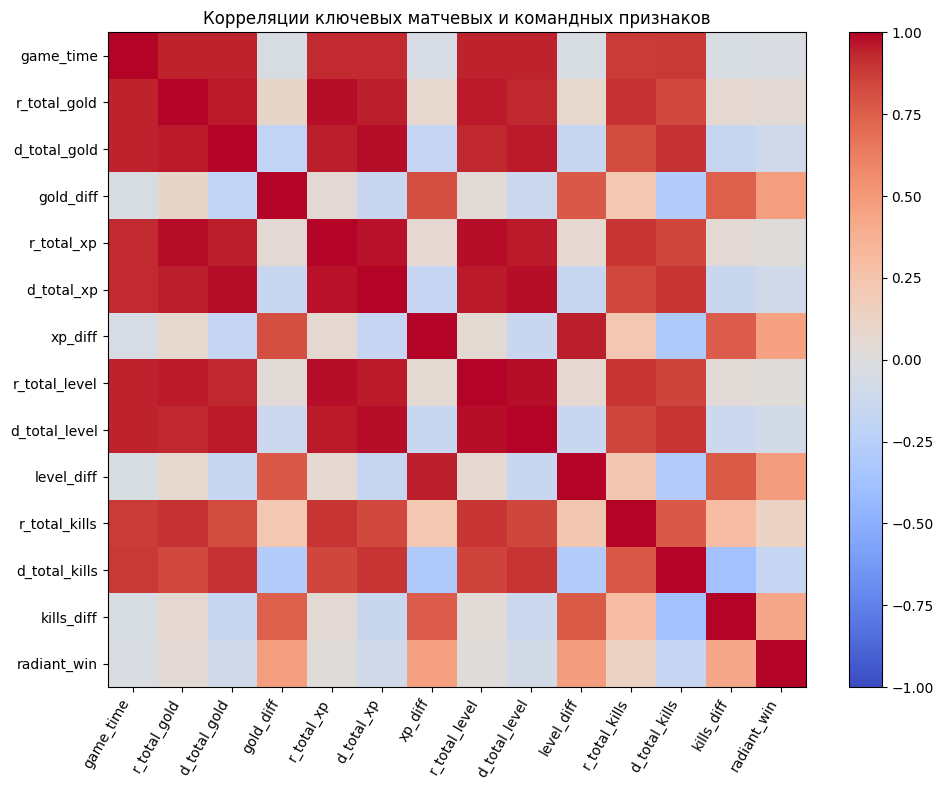

In [17]:
heat_cols = [
    "game_time",
    "r_total_gold", "d_total_gold", "gold_diff",
    "r_total_xp", "d_total_xp", "xp_diff",
    "r_total_level", "d_total_level", "level_diff",
    "r_total_kills", "d_total_kills", "kills_diff",
    "radiant_win"
]

heat_cols = [c for c in heat_cols if c in eda_team.columns]

corr = eda_team[heat_cols].corr()

plt.figure(figsize=(10, 8))
plt.imshow(corr.values, aspect="auto", cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar()

plt.xticks(range(len(heat_cols)), heat_cols, rotation=60, ha="right")
plt.yticks(range(len(heat_cols)), heat_cols)

plt.title("Корреляции ключевых матчевых и командных признаков")
plt.tight_layout()
plt.show()


На тепловой карте видно несколько ожидаемых и полезных для моделирования закономерностей.

1) **Сильная взаимосвязь между общими метриками темпа**
`r_total_gold`, `d_total_gold`, `r_total_xp`, `d_total_xp`, `r_total_level`, `d_total_level` заметно коррелируют между собой и с `game_time`. Это логично, чем больше времени прошло, тем больше накопленные ресурсы и уровни у обеих команд.

2) **Именно признаки преимущества выглядят наиболее связанными с таргетом**
Корреляции `gold_diff`, `xp_diff`, `level_diff`, `kills_diff` с `radiant_win` выраженно положительные. Это подтверждает гипотезу EDA, что для предсказания исхода важен не абсолютный фарм или количество убийств, а **разница между Radiant и Dire**.

3) **Абсолютные показатели команд слабее связаны с исходом**
Суммарные метрики Radiant и Dire по отдельности дают более размытый сигнал относительно `radiant_win`, чем их разницы. Поэтому в feature engineering имеет смысл делать упор на `*_diff` и при необходимости `*_ratio`.

4) **Боевой перевес связан с экономикой**
`r_total_kills` и `d_total_kills` коррелируют с экономическими и темповыми показателями, что отражает реальную игровую логику, успешные драки ускоряют набор золота и опыта.


### 4.7 Выбросы и аномальные значения

Рассмотрим выбросы и аномальные значения


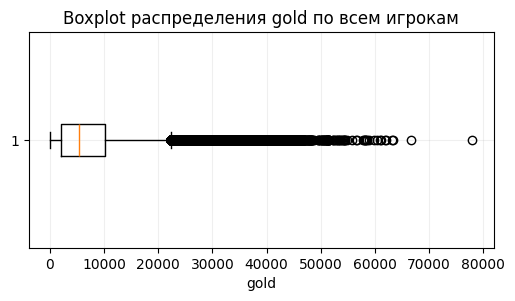

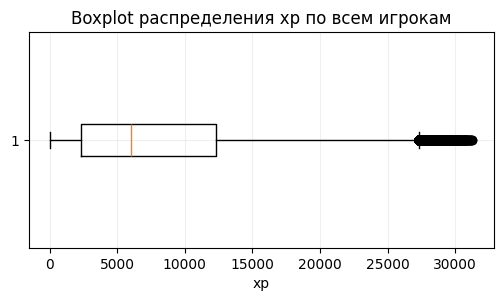

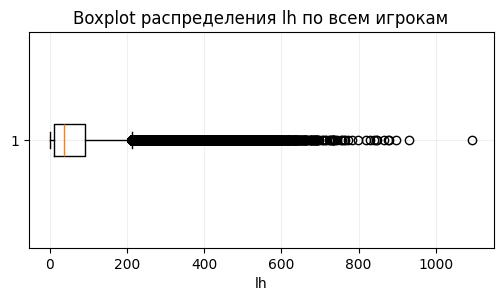

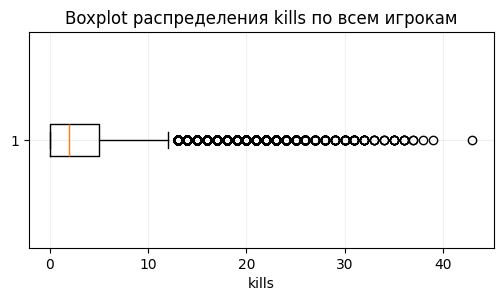

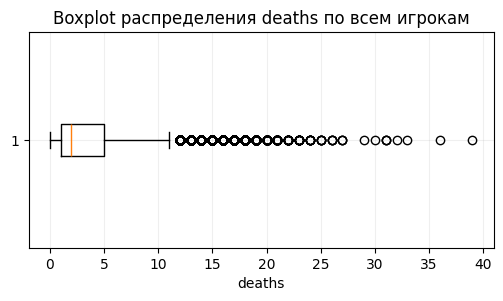

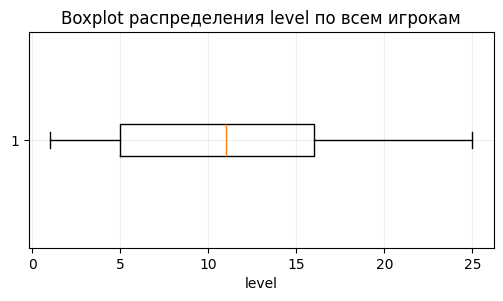

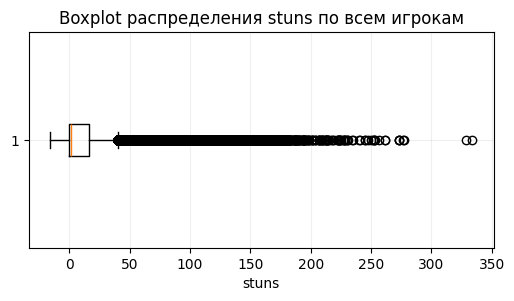

In [18]:
representative_stats = ["gold", "xp", "lh", "kills", "deaths", "level", "stuns"]

def make_team_long(df, stat):
    cols = []
    for i in range(1, 6):
        r = f"r{i}_{stat}"
        d = f"d{i}_{stat}"
        if r in df.columns:
            cols.append(r)
        if d in df.columns:
            cols.append(d)

    s = df[cols].stack().dropna()
    return s

for stat in representative_stats:
    s = make_team_long(raw_features, stat)
    if len(s) == 0:
        continue

    plt.figure(figsize=(6, 2.8))
    plt.boxplot(s, vert=False, showfliers=True)
    plt.title(f"Boxplot распределения {stat} по всем игрокам")
    plt.xlabel(stat)
    plt.grid(True, alpha=0.2)
    plt.show()


#### Вывод по выбросам

Анализ показал, что в ключевых числовых признаках ожидаемо есть хвостатые распределения, особенно в экономических и темповых метриках.  
При этом явных признаков "сломанных" данных не наблюдается.

Наиболее осмысленно учитывать это следующим образом:
- использовать командные агрегаты и разницы  
- при необходимости применять устойчивые преобразования при создании отдельных признаков  
- не удалять выбросы механически, так как в Dota 2 экстремальные значения могут быть реальными игровыми сценариями


# 5. Feature engineering и работа с сырыми данными

В этом разделе я перехожу от первичного анализа к созданию признаков, которые должны усилить сигнал для модели.  
В Dota 2 исход игры определяется не отдельными действиями игроков, а суммарным командным преимуществом, поэтому основной фокус feature engineering будет на агрегатах по командам и признаках разницы между Radiant и Dire на момент `game_time`.

Я использую два источника признаков:

1) **Подготовленные табличные данные (csv)**  
Здесь уже доступны основные числовые характеристики игроков. На их основе я создаю:
- командные суммы
- разницы и отношения по ключевым метрикам  
  например золото, опыт, уровни, убийства, фарм

2) **Сырые данные матчей (jsonl)**  
Этот источник опционален, но потенциально полезен для улучшения качества.  
Из него можно извлекать:
- дополнительные статистики игроков
- агрегаты по логам событий
- показать динамики из временных рядов `_t`

Важно, что любые признаки, связанные с таргет-статистиками героев, я рассчитываю аккуратно внутри кросс-валидации, чтобы избежать утечки данных.

Далее я последовательно построю набор осмысленных агрегированных признаков и покажу, как они влияют на качество модели.



Функция для вытаскивания фичей из таблицы с сырыми данными.

In [19]:
def attach_player_feature(raw_features, df_matches, feature: str, overwrite=False):
    """
    Добавляет к raw_features фичу по игрокам из df_matches["players"].
    Колонки будут вида r1_<feature>, ..., r5_<feature>, d1_<feature>, ..., d5_<feature>.
    Джойн по match_id_hash.
    
    """

    def extract_for_match(players):
        row = {}
        for p in players:
            slot = p.get("player_slot")
            if slot is None:
                continue

            if slot < 128:
                prefix = "r"
                idx = slot + 1
            else:
                prefix = "d"
                idx = slot - 128 + 1

            col_name = f"{prefix}{idx}_{feature}"
            row[col_name] = p.get(feature)

        return pd.Series(row)

    tmp = df_matches[["match_id_hash", "players"]].copy()
    features_df = tmp["players"].apply(extract_for_match)
    tmp = pd.concat([tmp[["match_id_hash"]], features_df], axis=1)

 
    left = raw_features.set_index("match_id_hash")
    right = tmp.set_index("match_id_hash")

    if not overwrite:
        new_cols = [c for c in right.columns if c not in left.columns]
        right = right[new_cols]

    result = left.join(right, how="left").reset_index()
    return result



In [20]:
raw_features = attach_player_feature(raw_features, df_json_matches,
    feature="pred_vict"
)

raw_features = attach_player_feature(raw_features, df_json_matches,
    feature="xp"
)

raw_features = attach_player_feature(raw_features, df_json_matches,
    feature="hero_name"
)

Для наглядности _hero_id можно заменить на имена героев.

In [21]:
def fix_hero_names_inplace(df):
    """
    In-place убирает префикс 'npc_dota_hero_' из колонок с именами героев.
    Правит все колонки, которые заканчиваются на '_hero_name'.
    
    Возвращает df для удобства, но изменяет его на месте.
    """
    hero_cols = [c for c in df.columns if c.endswith("_hero_name")]

    for col in hero_cols:
        df[col] = (
            df[col]
            .astype("string")
            .str.replace(r"^npc_dota_hero_", "", regex=True)
        )

    return df


In [22]:
raw_features = fix_hero_names_inplace(raw_features)

Можно создать аггрегированную табличку вероятности победы того или иного героя. От выбора героя может зависеть победа команды. Это target encoding. Сейчас я создам общую таблицу, но для того чтобы честно оценивать мои модели, эту таблицу надо создавать для каждого фолда чтобы предотвратить утечку данных. Поэтому создам универсальную функцию.

In [23]:
def hero_winrate_table(
    df,
    target_col="radiant_win",
    hero_cols=None,
    min_games=1
):
    """
    Считает винрейт героев, когда таргет уже находится в том же DataFrame.

    df: DataFrame с match_id_hash, колонками r?_hero_name, d?_hero_name и target_col
    target_col: 1 если выиграл Radiant, 0 если Dire
    hero_cols: список колонок героев. Если None, возьмёт все *_hero_name
    min_games: минимальное число игр героя для попадания в итоговую таблицу

    Возвращает DataFrame: hero_name, games, wins, winrate (по убыванию winrate)
    """

    if hero_cols is None:
        hero_cols = [c for c in df.columns if c.endswith("_hero_name")]

    def is_player_hero_col(c):
        return (
            len(c) >= 3
            and c[0] in ("r", "d")
            and c[1].isdigit()
            and c.endswith("_hero_name")
        )

    hero_cols = [c for c in hero_cols if is_player_hero_col(c)]

    base = df[hero_cols + [target_col]].copy()

    long_df = base.melt(
        id_vars=[target_col],
        value_vars=hero_cols,
        var_name="slot_col",
        value_name="hero_name"
    ).dropna(subset=["hero_name"])

    long_df["side"] = long_df["slot_col"].str[0]

    long_df["hero_win"] = long_df[target_col].where(
        long_df["side"] == "r",
        1 - long_df[target_col]
    )

    agg = (
        long_df
        .groupby("hero_name", as_index=False)
        .agg(
            games=("hero_win", "count"),
            wins=("hero_win", "sum")
        )
    )

    agg["winrate"] = agg["wins"] / agg["games"]

    agg = agg[agg["games"] >= min_games]
    agg = agg.sort_values(["winrate", "games"], ascending=[False, False]).reset_index(drop=True)

    return agg

In [24]:
hero_cols = [f"r{i}_hero_name" for i in range(1, 6)] + [f"d{i}_hero_name" for i in range(1, 6)]

wr_table = hero_winrate_table(
    raw_features,
    target_col="radiant_win",
    hero_cols=hero_cols,
    min_games=20
)


Таблица аггрегирующая все данные. (первые 10 героев)

In [25]:
wr_table.head(10)

,hero_name,games,wins,winrate
0,visage,1452,888,0.61157
1,riki,9497,5488,0.577867
2,zuus,5378,3098,0.576051
3,spectre,2481,1416,0.570738
4,abaddon,1983,1104,0.556732
5,vengefulspirit,2852,1577,0.552945
6,centaur,1689,932,0.551806
7,abyssal_underlord,3687,2034,0.551668
8,chaos_knight,3028,1658,0.547556
9,skeleton_king,6735,3681,0.546548


Эта функция добавляет этот винрейт к нашим признакам.

In [26]:
def add_hero_winrate_features(
    features_df,
    wr_table,
    hero_cols=None,
    hero_name_col="hero_name",
    winrate_col="winrate",
    fill_value=None
):
    if hero_cols is None:
        hero_cols = [c for c in features_df.columns if c.endswith("_hero_name")]

    mapping = wr_table.set_index(hero_name_col)[winrate_col]

    if fill_value is None:
        fill_value = float(wr_table[winrate_col].mean()) if len(wr_table) else 0.5

    for col in hero_cols:
        new_col = col.replace("_hero_name", "_hero_winrate")

        mapped = features_df[col].map(mapping)
        mapped = pd.to_numeric(mapped, errors="coerce")

        features_df[new_col] = mapped.fillna(fill_value)

    return features_df


In [27]:
hero_cols = [f"r{i}_hero_name" for i in range(1, 6)] + [f"d{i}_hero_name" for i in range(1, 6)]

raw_features = add_hero_winrate_features(
    raw_features,
    wr_table,
    hero_cols=hero_cols
)


In [28]:
raw_features.head(2)

,match_id_hash,game_time,game_mode,lobby_type,objectives_len,chat_len,r1_hero_id,r1_kills,r1_deaths,r1_assists,r1_denies,r1_gold,r1_lh,r1_xp,r1_health,r1_max_health,r1_max_mana,r1_level,r1_x,r1_y,r1_stuns,r1_creeps_stacked,r1_camps_stacked,r1_rune_pickups,r1_firstblood_claimed,r1_teamfight_participation,r1_towers_killed,r1_roshans_killed,r1_obs_placed,r1_sen_placed,r2_hero_id,r2_kills,r2_deaths,r2_assists,r2_denies,r2_gold,r2_lh,r2_xp,r2_health,r2_max_health,r2_max_mana,r2_level,r2_x,r2_y,r2_stuns,r2_creeps_stacked,r2_camps_stacked,r2_rune_pickups,r2_firstblood_claimed,r2_teamfight_participation,r2_towers_killed,r2_roshans_killed,r2_obs_placed,r2_sen_placed,r3_hero_id,r3_kills,r3_deaths,r3_assists,r3_denies,r3_gold,r3_lh,r3_xp,r3_health,r3_max_health,r3_max_mana,r3_level,r3_x,r3_y,r3_stuns,r3_creeps_stacked,r3_camps_stacked,r3_rune_pickups,r3_firstblood_claimed,r3_teamfight_participation,r3_towers_killed,r3_roshans_killed,r3_obs_placed,r3_sen_placed,r4_hero_id,r4_kills,r4_deaths,r4_assists,r4_denies,r4_gold,r4_lh,r4_xp,r4_health,r4_max_health,r4_max_mana,r4_level,r4_x,r4_y,r4_stuns,r4_creeps_stacked,r4_camps_stacked,r4_rune_pickups,r4_firstblood_claimed,r4_teamfight_participation,r4_towers_killed,r4_roshans_killed,r4_obs_placed,r4_sen_placed,r5_hero_id,r5_kills,r5_deaths,r5_assists,r5_denies,r5_gold,r5_lh,r5_xp,r5_health,r5_max_health,r5_max_mana,r5_level,r5_x,r5_y,r5_stuns,r5_creeps_stacked,r5_camps_stacked,r5_rune_pickups,r5_firstblood_claimed,r5_teamfight_participation,r5_towers_killed,r5_roshans_killed,r5_obs_placed,r5_sen_placed,d1_hero_id,d1_kills,d1_deaths,d1_assists,d1_denies,d1_gold,d1_lh,d1_xp,d1_health,d1_max_health,d1_max_mana,d1_level,d1_x,d1_y,d1_stuns,d1_creeps_stacked,d1_camps_stacked,d1_rune_pickups,d1_firstblood_claimed,d1_teamfight_participation,d1_towers_killed,d1_roshans_killed,d1_obs_placed,d1_sen_placed,d2_hero_id,d2_kills,d2_deaths,d2_assists,d2_denies,d2_gold,d2_lh,d2_xp,d2_health,d2_max_health,d2_max_mana,d2_level,d2_x,d2_y,d2_stuns,d2_creeps_stacked,d2_camps_stacked,d2_rune_pickups,d2_firstblood_claimed,d2_teamfight_participation,d2_towers_killed,d2_roshans_killed,d2_obs_placed,d2_sen_placed,d3_hero_id,d3_kills,d3_deaths,d3_assists,d3_denies,d3_gold,d3_lh,d3_xp,d3_health,d3_max_health,d3_max_mana,d3_level,d3_x,d3_y,d3_stuns,d3_creeps_stacked,d3_camps_stacked,d3_rune_pickups,d3_firstblood_claimed,d3_teamfight_participation,d3_towers_killed,d3_roshans_killed,d3_obs_placed,d3_sen_placed,d4_hero_id,d4_kills,d4_deaths,d4_assists,d4_denies,d4_gold,d4_lh,d4_xp,d4_health,d4_max_health,d4_max_mana,d4_level,d4_x,d4_y,d4_stuns,d4_creeps_stacked,d4_camps_stacked,d4_rune_pickups,d4_firstblood_claimed,d4_teamfight_participation,d4_towers_killed,d4_roshans_killed,d4_obs_placed,d4_sen_placed,d5_hero_id,d5_kills,d5_deaths,d5_assists,d5_denies,d5_gold,d5_lh,d5_xp,d5_health,d5_max_health,d5_max_mana,d5_level,d5_x,d5_y,d5_stuns,d5_creeps_stacked,d5_camps_stacked,d5_rune_pickups,d5_firstblood_claimed,d5_teamfight_participation,d5_towers_killed,d5_roshans_killed,d5_obs_placed,d5_sen_placed,radiant_win,r1_pred_vict,r2_pred_vict,r3_pred_vict,r4_pred_vict,r5_pred_vict,d1_pred_vict,d2_pred_vict,d3_pred_vict,d4_pred_vict,d5_pred_vict,r1_hero_name,r2_hero_name,r3_hero_name,r4_hero_name,r5_hero_name,d1_hero_name,d2_hero_name,d3_hero_name,d4_hero_name,d5_hero_name,r1_hero_winrate,r2_hero_winrate,r3_hero_winrate,r4_hero_winrate,r5_hero_winrate,d1_hero_winrate,d2_hero_winrate,d3_hero_winrate,d4_hero_winrate,d5_hero_winrate
0,a400b8f29dece5f4d266f49f1ae2e98a,155,22,7,1,11,11,0,0,0,0,543,7,533,358,600,350.93784,2,116,122,0.0,0,0,1,0,0.0000,0,0,0,0,78,0,0,0,3,399,4,478,636,720,254.93774,2,124,126,0.000000,0,0,0,0,0.0000,0,0,0,0,14,0,1,0,0,304,0,130,700,700,242.93773,1,70,156,0.000000,0,0,1,0,0.0000,0,0,0,0,59,0,0,0,1,389,4,506,399,700,326.93780,2,170,86,0.0,0,0,0,0,0.0000,0,0,0,0,77,0,0,0,0,402,10,344,422,800,314.93780,2,120,100,0.000000,0,0,0,0,0.000,0,0,0,0,12,0,0,1,13,982,12,780,650,720,386.93787,3,82,170,0.000000,0,0,1,0,1.00,0,0,

Дальше нужно обработать "урон" игроков. Извлекаем урон для каждого игрока.

In [29]:
raw_features = attach_player_feature(raw_features, df_json_matches,
    feature="damage"
)

Пример полученных данных. Тут записан урон от этого игрока (r1) по другим игрокам 'npc_dota_hero_<hero_name>' или по другим целям (нейтральным, крипам, рошану, зданиям и т.п.)

In [30]:
raw_features["r1_damage"][1]

{'npc_dota_hero_pudge': 2298,
 'npc_dota_hero_clinkz': 2151,
 'npc_dota_creep_goodguys_melee': 719,
 'npc_dota_creep_badguys_melee': 10986,
 'npc_dota_creep_goodguys_ranged': 149,
 'npc_dota_creep_badguys_ranged': 3452,
 'npc_dota_neutral_centaur_outrunner': 81,
 'npc_dota_badguys_siege': 540,
 'npc_dota_badguys_tower1_bot': 184,
 'npc_dota_neutral_polar_furbolg_champion': 115,
 'npc_dota_hero_enchantress': 100,
 'npc_dota_hero_antimage': 107}

Следующей функцией создадим 2 фичи. Урон по другим игрокам и общий урон.

In [31]:
def add_damage_features(df):
    """
    Ищет колонки, заканчивающиеся на _damage, где значения это dict.
    Добавляет
    1) <player>_total_damage  сумма всего урона
    2) <player>_hero_damage   сумма урона только по героям
    
    """

    damage_cols = [c for c in df.columns if c.endswith("_damage")]

    def total_damage(d):
        if not isinstance(d, dict):
            return 0
        return sum(d.values())

    def hero_damage(d):
        if not isinstance(d, dict):
            return 0
        return sum(v for k, v in d.items() if isinstance(k, str) and k.startswith("npc_dota_hero_"))

    for col in damage_cols:
        player = col.replace("_damage", "")  

        df[f"{player}_total_damage"] = df[col].apply(total_damage)
        df[f"{player}_hero_damage"] = df[col].apply(hero_damage)

    return df


In [32]:
raw_features = add_damage_features(raw_features)

Создадим аггрегаты всех фичей по командно и также разницу по 

In [33]:
raw_features.head(2)

,match_id_hash,game_time,game_mode,lobby_type,objectives_len,chat_len,r1_hero_id,r1_kills,r1_deaths,r1_assists,r1_denies,r1_gold,r1_lh,r1_xp,r1_health,r1_max_health,r1_max_mana,r1_level,r1_x,r1_y,r1_stuns,r1_creeps_stacked,r1_camps_stacked,r1_rune_pickups,r1_firstblood_claimed,r1_teamfight_participation,r1_towers_killed,r1_roshans_killed,r1_obs_placed,r1_sen_placed,r2_hero_id,r2_kills,r2_deaths,r2_assists,r2_denies,r2_gold,r2_lh,r2_xp,r2_health,r2_max_health,r2_max_mana,r2_level,r2_x,r2_y,r2_stuns,r2_creeps_stacked,r2_camps_stacked,r2_rune_pickups,r2_firstblood_claimed,r2_teamfight_participation,r2_towers_killed,r2_roshans_killed,r2_obs_placed,r2_sen_placed,r3_hero_id,r3_kills,r3_deaths,r3_assists,r3_denies,r3_gold,r3_lh,r3_xp,r3_health,r3_max_health,r3_max_mana,r3_level,r3_x,r3_y,r3_stuns,r3_creeps_stacked,r3_camps_stacked,r3_rune_pickups,r3_firstblood_claimed,r3_teamfight_participation,r3_towers_killed,r3_roshans_killed,r3_obs_placed,r3_sen_placed,r4_hero_id,r4_kills,r4_deaths,r4_assists,r4_denies,r4_gold,r4_lh,r4_xp,r4_health,r4_max_health,r4_max_mana,r4_level,r4_x,r4_y,r4_stuns,r4_creeps_stacked,r4_camps_stacked,r4_rune_pickups,r4_firstblood_claimed,r4_teamfight_participation,r4_towers_killed,r4_roshans_killed,r4_obs_placed,r4_sen_placed,r5_hero_id,r5_kills,r5_deaths,r5_assists,r5_denies,r5_gold,r5_lh,r5_xp,r5_health,r5_max_health,r5_max_mana,r5_level,r5_x,r5_y,r5_stuns,r5_creeps_stacked,r5_camps_stacked,r5_rune_pickups,r5_firstblood_claimed,r5_teamfight_participation,r5_towers_killed,r5_roshans_killed,r5_obs_placed,r5_sen_placed,d1_hero_id,d1_kills,d1_deaths,d1_assists,d1_denies,d1_gold,d1_lh,d1_xp,d1_health,d1_max_health,d1_max_mana,d1_level,d1_x,d1_y,d1_stuns,d1_creeps_stacked,d1_camps_stacked,d1_rune_pickups,d1_firstblood_claimed,d1_teamfight_participation,d1_towers_killed,d1_roshans_killed,d1_obs_placed,d1_sen_placed,d2_hero_id,d2_kills,d2_deaths,d2_assists,d2_denies,d2_gold,d2_lh,d2_xp,d2_health,d2_max_health,d2_max_mana,d2_level,d2_x,d2_y,d2_stuns,d2_creeps_stacked,d2_camps_stacked,d2_rune_pickups,d2_firstblood_claimed,d2_teamfight_participation,d2_towers_killed,d2_roshans_killed,d2_obs_placed,d2_sen_placed,d3_hero_id,d3_kills,d3_deaths,d3_assists,d3_denies,d3_gold,d3_lh,d3_xp,d3_health,d3_max_health,d3_max_mana,d3_level,d3_x,d3_y,d3_stuns,d3_creeps_stacked,d3_camps_stacked,d3_rune_pickups,d3_firstblood_claimed,d3_teamfight_participation,d3_towers_killed,d3_roshans_killed,d3_obs_placed,d3_sen_placed,d4_hero_id,d4_kills,d4_deaths,d4_assists,d4_denies,d4_gold,d4_lh,d4_xp,d4_health,d4_max_health,d4_max_mana,d4_level,d4_x,d4_y,d4_stuns,d4_creeps_stacked,d4_camps_stacked,d4_rune_pickups,d4_firstblood_claimed,d4_teamfight_participation,d4_towers_killed,d4_roshans_killed,d4_obs_placed,d4_sen_placed,d5_hero_id,d5_kills,d5_deaths,d5_assists,d5_denies,d5_gold,d5_lh,d5_xp,d5_health,d5_max_health,d5_max_mana,d5_level,d5_x,d5_y,d5_stuns,d5_creeps_stacked,d5_camps_stacked,d5_rune_pickups,d5_firstblood_claimed,d5_teamfight_participation,d5_towers_killed,d5_roshans_killed,d5_obs_placed,d5_sen_placed,radiant_win,r1_pred_vict,r2_pred_vict,r3_pred_vict,r4_pred_vict,r5_pred_vict,d1_pred_vict,d2_pred_vict,d3_pred_vict,d4_pred_vict,d5_pred_vict,r1_hero_name,r2_hero_name,r3_hero_name,r4_hero_name,r5_hero_name,d1_hero_name,d2_hero_name,d3_hero_name,d4_hero_name,d5_hero_name,r1_hero_winrate,r2_hero_winrate,r3_hero_winrate,r4_hero_winrate,r5_hero_winrate,d1_hero_winrate,d2_hero_winrate,d3_hero_winrate,d4_hero_winrate,d5_hero_winrate,r1_damage,r2_damage,r3_damage,r4_damage,r5_damage,d1_damage,d2_damage,d3_damage,d4_damage,d5_damage,r1_total_damage,r1_hero_damage,r2_total_damage,r2_hero_damage,r3_total_damage,r3_hero_damage,r4_total_damage,r4_hero_damage,r5_total_damage,r5_hero_damage,d1_total_damage,d1_hero_damage,d2_total_damage,d2_hero_damage,d3_total_damage,d3_hero_damage,d4_total_damage,d4_hero_damage,d5_total_damage,d5_hero_damage
0,a400b8f29dece5f4d266f49f1ae2e98a,155,22,7,1,11,11,0,0,0,0,543,7,533,358,600,350.93784,2,116,122,0.0,0,0,1,

In [34]:
def create_features(df):
    # какие характеристики суммируем для каждой команды
    metrics = ["gold", 'stuns', "max_health", "kills", "max_mana", "deaths", "level", "xp" , "teamfight_participation","hero_damage", "towers_killed", "total_damage", "roshans_killed", "sen_placed", "obs_placed", "hero_winrate"]

    for m in metrics:
        # radiant
        r_cols = [f"r{i}_{m}" for i in range(1, 6)]
        df[f"radiant_total_{m}"] = df[r_cols].sum(axis=1)

        # dire
        d_cols = [f"d{i}_{m}" for i in range(1, 6)]
        df[f"dire_total_{m}"] = df[d_cols].sum(axis=1)

        # разница
        df[f"radiant_{m}_advantage"] = df[f"radiant_total_{m}"] - df[f"dire_total_{m}"]

    # итоговая метрика убийств и смертей
    df["total_kills_deaths"] = (
        df["radiant_total_kills"] +
        df["dire_total_kills"] +
        df["radiant_total_deaths"] +
        df["dire_total_deaths"]
    )
    
    return df

In [35]:
raw_features = create_features(raw_features)

In [36]:
raw_features.head(2)

,match_id_hash,game_time,game_mode,lobby_type,objectives_len,chat_len,r1_hero_id,r1_kills,r1_deaths,r1_assists,r1_denies,r1_gold,r1_lh,r1_xp,r1_health,r1_max_health,r1_max_mana,r1_level,r1_x,r1_y,r1_stuns,r1_creeps_stacked,r1_camps_stacked,r1_rune_pickups,r1_firstblood_claimed,r1_teamfight_participation,r1_towers_killed,r1_roshans_killed,r1_obs_placed,r1_sen_placed,r2_hero_id,r2_kills,r2_deaths,r2_assists,r2_denies,r2_gold,r2_lh,r2_xp,r2_health,r2_max_health,r2_max_mana,r2_level,r2_x,r2_y,r2_stuns,r2_creeps_stacked,r2_camps_stacked,r2_rune_pickups,r2_firstblood_claimed,r2_teamfight_participation,r2_towers_killed,r2_roshans_killed,r2_obs_placed,r2_sen_placed,r3_hero_id,r3_kills,r3_deaths,r3_assists,r3_denies,r3_gold,r3_lh,r3_xp,r3_health,r3_max_health,r3_max_mana,r3_level,r3_x,r3_y,r3_stuns,r3_creeps_stacked,r3_camps_stacked,r3_rune_pickups,r3_firstblood_claimed,r3_teamfight_participation,r3_towers_killed,r3_roshans_killed,r3_obs_placed,r3_sen_placed,r4_hero_id,r4_kills,r4_deaths,r4_assists,r4_denies,r4_gold,r4_lh,r4_xp,r4_health,r4_max_health,r4_max_mana,r4_level,r4_x,r4_y,r4_stuns,r4_creeps_stacked,r4_camps_stacked,r4_rune_pickups,r4_firstblood_claimed,r4_teamfight_participation,r4_towers_killed,r4_roshans_killed,r4_obs_placed,r4_sen_placed,r5_hero_id,r5_kills,r5_deaths,r5_assists,r5_denies,r5_gold,r5_lh,r5_xp,r5_health,r5_max_health,r5_max_mana,r5_level,r5_x,r5_y,r5_stuns,r5_creeps_stacked,r5_camps_stacked,r5_rune_pickups,r5_firstblood_claimed,r5_teamfight_participation,r5_towers_killed,r5_roshans_killed,r5_obs_placed,r5_sen_placed,d1_hero_id,d1_kills,d1_deaths,d1_assists,d1_denies,d1_gold,d1_lh,d1_xp,d1_health,d1_max_health,d1_max_mana,d1_level,d1_x,d1_y,d1_stuns,d1_creeps_stacked,d1_camps_stacked,d1_rune_pickups,d1_firstblood_claimed,d1_teamfight_participation,d1_towers_killed,d1_roshans_killed,d1_obs_placed,d1_sen_placed,d2_hero_id,d2_kills,d2_deaths,d2_assists,d2_denies,d2_gold,d2_lh,d2_xp,d2_health,d2_max_health,d2_max_mana,d2_level,d2_x,d2_y,d2_stuns,d2_creeps_stacked,d2_camps_stacked,d2_rune_pickups,d2_firstblood_claimed,d2_teamfight_participation,d2_towers_killed,d2_roshans_killed,d2_obs_placed,d2_sen_placed,d3_hero_id,d3_kills,d3_deaths,d3_assists,d3_denies,d3_gold,d3_lh,d3_xp,d3_health,d3_max_health,d3_max_mana,d3_level,d3_x,d3_y,d3_stuns,d3_creeps_stacked,d3_camps_stacked,d3_rune_pickups,d3_firstblood_claimed,d3_teamfight_participation,d3_towers_killed,d3_roshans_killed,d3_obs_placed,d3_sen_placed,d4_hero_id,d4_kills,d4_deaths,d4_assists,d4_denies,d4_gold,d4_lh,d4_xp,d4_health,d4_max_health,d4_max_mana,d4_level,d4_x,d4_y,d4_stuns,d4_creeps_stacked,d4_camps_stacked,d4_rune_pickups,d4_firstblood_claimed,d4_teamfight_participation,d4_towers_killed,d4_roshans_killed,d4_obs_placed,d4_sen_placed,d5_hero_id,d5_kills,d5_deaths,d5_assists,d5_denies,d5_gold,d5_lh,d5_xp,d5_health,d5_max_health,d5_max_mana,d5_level,d5_x,d5_y,d5_stuns,d5_creeps_stacked,d5_camps_stacked,d5_rune_pickups,d5_firstblood_claimed,d5_teamfight_participation,d5_towers_killed,d5_roshans_killed,d5_obs_placed,d5_sen_placed,radiant_win,r1_pred_vict,r2_pred_vict,r3_pred_vict,r4_pred_vict,r5_pred_vict,d1_pred_vict,d2_pred_vict,d3_pred_vict,d4_pred_vict,d5_pred_vict,r1_hero_name,r2_hero_name,r3_hero_name,r4_hero_name,r5_hero_name,d1_hero_name,d2_hero_name,d3_hero_name,d4_hero_name,d5_hero_name,r1_hero_winrate,r2_hero_winrate,r3_hero_winrate,r4_hero_winrate,r5_hero_winrate,d1_hero_winrate,d2_hero_winrate,d3_hero_winrate,d4_hero_winrate,d5_hero_winrate,r1_damage,r2_damage,r3_damage,r4_damage,r5_damage,d1_damage,d2_damage,d3_damage,d4_damage,d5_damage,r1_total_damage,r1_hero_damage,r2_total_damage,r2_hero_damage,r3_total_damage,r3_hero_damage,r4_total_damage,r4_hero_damage,r5_total_damage,r5_hero_damage,d1_total_damage,d1_hero_damage,d2_total_damage,d2_hero_damage,d3_total_damage,d3_hero_damage,d4_total_damage,d4_hero_damage,d5_total_damage,d5_hero_damage,radiant_total_gold,dire_total_gold,radiant_gold_advantage,radiant_total_stuns,dire_total_stuns,radiant_stuns

Извлечем временые ряды по признакам: gold, experience, last hits, denies.

In [37]:
raw_features = attach_player_feature(raw_features, df_json_matches,
    feature="gold_t"
)
raw_features = attach_player_feature(raw_features, df_json_matches,
    feature="xp_t"
)
raw_features = attach_player_feature(raw_features, df_json_matches,
    feature="lh_t"
)
raw_features = attach_player_feature(raw_features, df_json_matches,
    feature="dn_t"
)

Наглядная функция чтобы посмотреть на изменения золота/опыта/last hits/denies со временем у каждого игрока.

In [38]:
def match_timeseries_widget_random(df, idx=0, time_step=60):
    metrics = {
        "gold_t": "Gold networth",
        "xp_t": "XP",
        "lh_t": "Last hits",
        "dn_t": "Denies",
    }

    players = [f"r{i}" for i in range(1, 6)] + [f"d{i}" for i in range(1, 6)]

    out = widgets.Output()

    dropdown = widgets.Dropdown(
        options=[(label, key) for key, label in metrics.items()],
        value="gold_t",
        description="Metric",
        layout=widgets.Layout(width="260px")
    )

    btn_random = widgets.Button(
        description="Random match",
        button_style="",
        icon="random",
        layout=widgets.Layout(width="150px")
    )

    idx_label = widgets.HTML()

    state = {"idx": idx}

    def coerce_list(val):
        if val is None:
            return []
        if isinstance(val, (list, tuple)):
            return list(val)
        if isinstance(val, str):
            s = val.strip()
            if s.startswith("[") and s.endswith("]"):
                try:
                    parsed = ast.literal_eval(s)
                    if isinstance(parsed, list):
                        return parsed
                except Exception:
                    return []
        return []

    def get_series(row, p, metric):
        col = f"{p}_{metric}"
        if col not in row.index:
            return []
        return coerce_list(row[col])

    def update_label(row_idx):
        text = f"<b>idx:</b> {row_idx}"
        idx_label.value = text

    def plot():
        row_idx = state["idx"]
        metric = dropdown.value
        row = df.iloc[row_idx]

        with out:
            clear_output(wait=True)

            plt.figure(figsize=(10, 6))

            plotted_any = False
            max_len = 0

            for p in players:
                values = get_series(row, p, metric)
                if not values:
                    continue

                max_len = max(max_len, len(values))
                times = [i * time_step for i in range(len(values))]
                color = "green" if p.startswith("r") else "red"

                plt.plot(times, values, color=color, alpha=0.9)
                plotted_any = True

            if not plotted_any:
                print(
                    f"Для строки idx={row_idx} нет данных {metric}. "
                    f"Проверь, что колонки r1_{metric} ... d5_{metric} прикреплены "
                    f"и что в этой строке они не пустые"
                )
                return

            plt.xlabel("Time, sec")
            plt.ylabel(metrics[metric])
            plt.title(f"{metrics[metric]} for all players, idx = {row_idx}")

            if max_len > 1:
                plt.xlim(0, (max_len - 1) * time_step)

            legend_handles = [
                Line2D([0], [0], color="green", lw=2, label="Radiant"),
                Line2D([0], [0], color="red", lw=2, label="Dire"),
            ]
            plt.legend(handles=legend_handles, loc="upper left")

            plt.tight_layout()
            plt.show()

    def on_metric_change(change):
        if change.get("name") == "value":
            update_label(state["idx"])
            plot()

    def on_random_click(_):
        state["idx"] = random.randrange(0, len(df))
        update_label(state["idx"])
        plot()

    dropdown.observe(on_metric_change)
    btn_random.on_click(on_random_click)

    controls = widgets.HBox([dropdown, btn_random, idx_label])

    display(controls)
    display(out)

    update_label(state["idx"])
    plot()


Для наглядности был выбран самый длинный матч. Можно выбрать в dropdown меню статистику которую хотите посмотреть, а нажав "random match" выберется случайный другой матч. (если картинка отсутствует, значит матч был слишком коротким для отображения)

In [39]:
longest_match_id = df_train_matches['game_time'].idxmax()
match_timeseries_widget_random(raw_features, idx=longest_match_id)


Output()

Разделим наши данные для последующего моделирования

In [40]:
drop_suffixes = ("_damage", "_damage_taken", "_gold_t", "_lh_t", "_dn_t", "_xp_t")
drop_cols = [c for c in raw_features.columns if c.endswith(drop_suffixes)]

X = raw_features.drop(columns=drop_cols + ['match_id_hash', 'radiant_win'], errors="ignore")
y = raw_features["radiant_win"]


# 6. Моделирование

## Logistic regression

Построим несложный пайплайн

In [41]:
lr_preprocess = ColumnTransformer(
    transformers=[
        ("num", Pipeline(steps=[
            ("scaler", StandardScaler())
        ]), make_column_selector(dtype_include=np.number)),

        ("drop_hero_names", "drop", hero_cols),
    ],
    remainder="drop"
)

lr_model = LogisticRegression(
    max_iter=2000,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

lr_pipe = Pipeline(steps=[
    ("prep", lr_preprocess),
    ("model", lr_model)
])

Если я хочу учитывать winrate каждого героя мне нужно "честно" расчитать эту статистику внутри каждого фолда. Ниже функции которые создают табличку winrate и добавляют фичу к данным и переписывают раннее аггрегированные статистики по этому признаку.

In [42]:
def hero_winrate_table(
    df,
    target_col="radiant_win",
    hero_cols=None,
    min_games=1
):
    """
    Считает винрейт героев, когда таргет уже находится в df.

    df: DataFrame с колонками r?_hero_name, d?_hero_name и target_col
    target_col: 1 если выиграл Radiant, 0 если Dire
    hero_cols: список колонок героев. Если None, берём все *_hero_name
    min_games: минимальное число игр героя для попадания в итоговую таблицу

    Возвращает DataFrame: hero_name, games, wins, winrate (по убыванию winrate)
    """

    if hero_cols is None:
        hero_cols = [c for c in df.columns if c.endswith("_hero_name")]

    def is_player_hero_col(c):
        return (
            len(c) >= 3
            and c[0] in ("r", "d")
            and c[1].isdigit()
            and c.endswith("_hero_name")
        )

    hero_cols = [c for c in hero_cols if is_player_hero_col(c)]

    base = df[hero_cols + [target_col]].copy()

    long_df = base.melt(
        id_vars=[target_col],
        value_vars=hero_cols,
        var_name="slot_col",
        value_name="hero_name"
    ).dropna(subset=["hero_name"])

    long_df["side"] = long_df["slot_col"].str[0]

    long_df["hero_win"] = long_df[target_col].where(
        long_df["side"] == "r",
        1 - long_df[target_col]
    )

    agg = (
        long_df
        .groupby("hero_name", as_index=False)
        .agg(
            games=("hero_win", "count"),
            wins=("hero_win", "sum")
        )
    )

    agg["winrate"] = agg["wins"] / agg["games"]

    agg = agg[agg["games"] >= min_games]
    agg = agg.sort_values(["winrate", "games"], ascending=[False, False]).reset_index(drop=True)

    return agg


def add_hero_winrate_features(
    df,
    wr_table,
    hero_cols=None,
    hero_name_col="hero_name",
    winrate_col="winrate",
    fill_value=None,
    add_team_aggregates=True
):
    """
    Добавляет winrate-фичи для каждой hero-колонки и при желании
    пересчитывает командные агрегаты.

    Пример:
    r1_hero_name -> r1_hero_winrate
    ...
    d5_hero_name -> d5_hero_winrate

    Также (если add_team_aggregates=True) создаёт или перезаписывает:
    - radiant_total_hero_winrate
    - dire_total_hero_winrate
    - radiant_hero_winrate_advantage

    df изменяется in-place и возвращается для удобства.
    """

    # 1) hero_cols
    if hero_cols is None:
        hero_cols = [c for c in df.columns if c.endswith("_hero_name")]

    hero_cols = [c for c in hero_cols if c in df.columns]

    # 2) mapping hero -> winrate
    if wr_table is None or len(wr_table) == 0:
        mapping = pd.Series(dtype="float64")
    else:
        mapping = wr_table.set_index(hero_name_col)[winrate_col]

    
    if fill_value is None:
        fill_value = float(wr_table[winrate_col].mean()) if len(wr_table) else 0.5

    
    created_wr_cols = []

    for col in hero_cols:
        new_col = col.replace("_hero_name", "_hero_winrate")

        df[new_col] = (
            pd.to_numeric(df[col].map(mapping), errors="coerce")
              .astype("float64")
              .fillna(fill_value)
        )

        created_wr_cols.append(new_col)

    # 3) team агрегаты
    if add_team_aggregates:
        r_wr = [c for c in created_wr_cols if c.startswith("r")]
        d_wr = [c for c in created_wr_cols if c.startswith("d")]

        
        def slot_key(c):
            try:
                return int(c[1])
            except Exception:
                return 99

        r_wr = sorted(r_wr, key=slot_key)
        d_wr = sorted(d_wr, key=slot_key)

        df["radiant_total_hero_winrate"] = df[r_wr].sum(axis=1) if r_wr else 0.0
        df["dire_total_hero_winrate"] = df[d_wr].sum(axis=1) if d_wr else 0.0
        df["radiant_hero_winrate_advantage"] = (
            df["radiant_total_hero_winrate"] - df["dire_total_hero_winrate"]
        )

    return df


Функция для кросс валидации Логистической регрессии.

In [43]:
def cv_auc_train(
    model, X, y, hero_name_cols,
    n_splits=5, min_games=1, fill_value_mode="fold"
):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
    aucs = []

    y = y.astype(int)
    global_mean = y.mean().item()

    oof = np.zeros(len(X), dtype=float)

    for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y), start=1):
        X_tr = X.iloc[tr_idx].copy()
        X_val = X.iloc[val_idx].copy()
        y_tr = y.iloc[tr_idx]
        y_val = y.iloc[val_idx]

        # 1) считаем winrate-таблицу только на train части
        tr_for_wr = X_tr[hero_name_cols].copy()
        tr_for_wr["__target__"] = y_tr.values

        wr_table = hero_winrate_table(
            tr_for_wr,
            target_col="__target__",
            hero_cols=hero_name_cols,
            min_games=min_games
        )

        # 2) выбираем fill_value
        fill_value = y_tr.mean().item() if fill_value_mode == "fold" else global_mean

        # 3) добавляем winrate-фичи в train и val
        X_tr = add_hero_winrate_features(
            X_tr, wr_table, hero_cols=hero_name_cols, fill_value=fill_value
        )
        X_val = add_hero_winrate_features(
            X_val, wr_table, hero_cols=hero_name_cols, fill_value=fill_value
        )

        # 4) fit и оценка
        model.fit(X_tr, y_tr)
        pred = model.predict_proba(X_val)[:, 1]

        oof[val_idx] = pred

        auc = roc_auc_score(y_val, pred)
        aucs.append(auc)
        print(f"Fold {fold} AUC: {auc:.5f}")

    mean_auc = float(np.mean(aucs))
    std_auc = float(np.std(aucs))
    oof_auc = float(roc_auc_score(y, oof))

    print(f"OOF AUC: {oof_auc:.5f}")

    return {
        "fold_aucs": aucs,
        "mean_auc": mean_auc,
        "std_auc": std_auc,
        "oof_auc": oof_auc,
        "oof_pred": oof
    }


In [44]:
lr_res = cv_auc_train(
    lr_pipe, X, y,
    hero_name_cols=hero_cols,
    n_splits=5,
    min_games=1,
    fill_value_mode="fold"
)


print(f"Roc-auc: {lr_res['mean_auc']:.5g} | std: {lr_res['std_auc']:.5g}")

Fold 1 AUC: 0.82960
Fold 2 AUC: 0.82376
Fold 3 AUC: 0.82313
Fold 4 AUC: 0.83363
Fold 5 AUC: 0.84009
OOF AUC: 0.82997
Roc-auc: 0.83004 | std: 0.0063438


## Random Forest

In [45]:
rf_preprocess = ColumnTransformer(
    transformers=[
        ("drop_hero_names", "drop", hero_cols),
    ],
    remainder="passthrough"
)
rf_model = RandomForestClassifier(
    n_estimators=600,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1
)

rf_pipe = Pipeline(steps=[
    ("prep", rf_preprocess),
    ("model", rf_model)
])

In [46]:
rf_res  = cv_auc_train(
    rf_pipe, X, y,
    hero_name_cols=hero_cols,
    n_splits=5,
    min_games=1,
    fill_value_mode="fold"
)

print(f"Roc-auc: {rf_res['mean_auc']:.5g} | std: {rf_res['std_auc']:.5g}")


Fold 1 AUC: 0.82261
Fold 2 AUC: 0.82717
Fold 3 AUC: 0.82746
Fold 4 AUC: 0.83499
Fold 5 AUC: 0.83987
OOF AUC: 0.83035
Roc-auc: 0.83042 | std: 0.0061727


## Catboost

Также сделаем кросс валидацию на нескольких фолдах при этом будем учитывать winrate признаки чтобы избежать утечки данных.

In [47]:
def catboost_cv_with_fold_hero_winrate(
    X,
    y,
    hero_cols,
    target_col="radiant_win",
    n_splits=5,
    min_games=1,
    params=None,
    fill_value_mode="fold",   # "global" или "fold"
    drop_hero_names_in_model=False,
    verbose=200
):
    """
    CV для CatBoost, где на каждом фолде:
    1) считаем hero winrate table только на train части фолда
    2) добавляем *_hero_winrate фичи в train и val
    3) обучаем модель и считаем AUC

    X: DataFrame с фичами (должны быть hero_cols)
    y: Series таргета
    hero_cols: список колонок героев (r?_hero_name и d?_hero_name)
    target_col: имя таргета, используется только временно внутри расчёта winrate
    fill_value_mode:
        "global" - fill_value берется как среднее по всему y
        "fold"   - fill_value берется как среднее по y_tr текущего фолда
    drop_hero_names_in_model:
        True удалит исходные *_hero_name перед fit
    """

    
    if params is None:
        params = dict(
            iterations=5000,
            learning_rate=0.05,
            depth=7,
            l2_leaf_reg=3.0,
            loss_function="Logloss",
            eval_metric="AUC",
            random_seed=RANDOM_STATE,
            verbose=0
        )

    
    y = y.astype(int)


    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)

    aucs = []
    oof = np.zeros(len(X), dtype=float)
    models = []

    global_mean = y.mean().item()

    for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y), start=1):
        X_tr = X.iloc[tr_idx].copy()
        X_val = X.iloc[val_idx].copy()
        y_tr = y.iloc[tr_idx]
        y_val = y.iloc[val_idx]

        # 1) временный df только для winrate-таблицы
        tr_for_wr = X_tr[hero_cols].copy()
        tr_for_wr[target_col] = y_tr.values

        wr_table = hero_winrate_table(
            tr_for_wr,
            target_col=target_col,
            hero_cols=hero_cols,
            min_games=min_games
        )

        # 2) fill_value
        if fill_value_mode == "fold":
            fill_value = y_tr.mean().item()
        else:
            fill_value = global_mean

        # 3) добавляем winrate-фичи
        X_tr = add_hero_winrate_features(
            X_tr, wr_table, hero_cols=hero_cols, fill_value=fill_value
        )
        X_val = add_hero_winrate_features(
            X_val, wr_table, hero_cols=hero_cols, fill_value=fill_value
        )

        # 4) опционально удаляем исходные hero_name из обучения
        if drop_hero_names_in_model:
            X_tr = X_tr.drop(columns=hero_cols, errors="ignore")
            X_val = X_val.drop(columns=hero_cols, errors="ignore")

        # 5) fit
        model = CatBoostClassifier(**params)
        model.fit(
            X_tr, y_tr,
            eval_set=(X_val, y_val),
            use_best_model=True,
            early_stopping_rounds=200,
            verbose=verbose
        )

        pred = model.predict_proba(X_val)[:, 1]
        oof[val_idx] = pred

        auc = roc_auc_score(y_val, pred)
        aucs.append(auc)
        models.append(model)

        print(f"Fold {fold} AUC: {auc:.5f}")

    overall_auc = roc_auc_score(y, oof)
    print(f"OOF AUC: {overall_auc:.5f}")

    return {
        "fold_aucs": aucs,
        "mean_auc": float(np.mean(aucs)),
        "std_auc": float(np.std(aucs)),
        "oof_auc": float(overall_auc),
        "oof_pred": oof,
        "models": models,
        "used_params": params
    }


Подбор гиперпараметров. Осуществлен с помощью Optuna. Так как это долгий процесс (более часа) я предоставил уже подобранные гиперпараметры ниже. Если все же нужно запустить подбор - поменяйте TUNING на True в следующей ячейке.

In [48]:
TUNUNG = False

In [49]:
def optuna_objective(trial, X, y, hero_cols):
    params = dict(
        iterations=5000,  
        learning_rate=trial.suggest_float("learning_rate", 0.02, 0.2, log=True),
        depth=trial.suggest_int("depth", 4, 10),
        l2_leaf_reg=trial.suggest_float("l2_leaf_reg", 1.0, 20.0, log=True),
        random_strength=trial.suggest_float("random_strength", 0.0, 2.0),
        bagging_temperature=trial.suggest_float("bagging_temperature", 0.0, 2.0),
        subsample=trial.suggest_float("subsample", 0.6, 1.0),
        loss_function="Logloss",
        eval_metric="AUC",
        random_seed=RANDOM_STATE,
        verbose=0
    )

    res = catboost_cv_with_fold_hero_winrate(
        X=X,
        y=y,
        hero_cols=hero_cols,
        target_col="radiant_win",
        n_splits=5,
        min_games=1,
        params=params,
        fill_value_mode="fold",
        drop_hero_names_in_model=True,
        verbose=0
    )

    return res["mean_auc"]


In [50]:
def tune_catboost_optuna(X, y, hero_cols, n_trials=50):
    study = optuna.create_study(direction="maximize")
    study.optimize(lambda t: optuna_objective(t, X, y, hero_cols), n_trials=n_trials)

    print("Best AUC:", study.best_value)
    print("Best params:", study.best_params)
    return study

In [51]:
if TUNUNG:
    study = tune_catboost_optuna(X, y, hero_cols, n_trials=50)

Будут использованны лучшие подобранные параметры, либо те которые были подобранны заранее.

In [52]:
if TUNUNG:
    best_params = {
        **study.best_params,
        "iterations": 5000,
        "loss_function": "Logloss",
        "eval_metric": "AUC",
        "random_seed": RANDOM_STATE,
        "verbose": 200
    }

    print(best_params)
else:
    best_params = {'learning_rate': 0.021021603255904613,
                'depth': 8,
                'l2_leaf_reg': 10.573855601705766,
                'random_strength': 0.6283486262986154,
                'bagging_temperature': 0.7888749153985054,
                'subsample': 0.6632785596862757,
                'iterations': 5000,
                'loss_function': 'Logloss',
                'eval_metric': 'AUC',
                'random_seed': RANDOM_STATE,
                'verbose': 200}

Кросс валидация на 5 фолдах с лучшими гиперпараметрами.

In [53]:
results_cb = catboost_cv_with_fold_hero_winrate(
    X=X,
    y=y,
    hero_cols=hero_cols,
    target_col="radiant_win",
    n_splits=5,
    min_games=1,
    params=best_params,
    fill_value_mode="fold",
    drop_hero_names_in_model=True
)


print("Roc-auc:", f"{results_cb['mean_auc']:.5g}", "std:", f"{results_cb['std_auc']:.5g}")

0:	test: 0.8013405	best: 0.8013405 (0)	total: 170ms	remaining: 14m 10s
200:	test: 0.8303136	best: 0.8303136 (200)	total: 5.29s	remaining: 2m 6s
400:	test: 0.8316841	best: 0.8316841 (400)	total: 10.3s	remaining: 1m 57s
600:	test: 0.8327232	best: 0.8327296 (599)	total: 15.2s	remaining: 1m 51s
800:	test: 0.8334167	best: 0.8334448 (785)	total: 20s	remaining: 1m 44s
1000:	test: 0.8336925	best: 0.8336962 (999)	total: 24.8s	remaining: 1m 39s
1200:	test: 0.8338893	best: 0.8339061 (1183)	total: 29.7s	remaining: 1m 33s
1400:	test: 0.8338282	best: 0.8340001 (1242)	total: 34.5s	remaining: 1m 28s
Stopped by overfitting detector  (200 iterations wait)

bestTest = 0.8340001465
bestIteration = 1242

Shrink model to first 1243 iterations.
Fold 1 AUC: 0.83400
0:	test: 0.8061083	best: 0.8061083 (0)	total: 25.2ms	remaining: 2m 5s
200:	test: 0.8318070	best: 0.8318248 (199)	total: 4.83s	remaining: 1m 55s
400:	test: 0.8328722	best: 0.8328760 (399)	total: 9.52s	remaining: 1m 49s
600:	test: 0.8334249	best: 0.8

# 7. Оценка качества по метрике ROC-AUC и валидация

В качестве основной метрики качества в этом проекте я использую **ROC-AUC**, так как задача требует предсказать вероятность победы Radiant, а эта метрика оценивает качество ранжирования вероятностей и не зависит от выбранного порога классификации.

Напомню, что:
- **ROC-кривая** строится по значениям TPR и FPR при разных порогах
- **ROC-AUC = 0.5** соответствует случайному угадыванию
- Чем ближе ROC-AUC к 1.0, тем лучше модель отделяет победы Radiant от побед Dire

### 7.1 Схема валидации

Для сравнения моделей я использую **Stratified K-Fold cross-validation**, чтобы:
- сохранить баланс классов в каждом фолде
- получить более устойчивую оценку качества


Это предотвращает утечку целевой переменной и делает оценку честной.

### 7.2 Сравнение моделей по ROC-AUC

Я сравнил три модели:
- Logistic Regression
- RandomForest
- CatBoost

Оценка проводится по одинаковой схеме кросс-валидации и с одинаковыми наборами признаков, включая корректно рассчитанные fold-based hero winrate признаки.

**Сравнение моделей по ROC-AUC на кросс-валидации**

| Модель | Средний ROC-AUC (CV) | Std ROC-AUC |
|---|---:|---:|
| Logistic Regression | 0.83004 | 0.00634 |
| RandomForest | 0.83042 | 0.00617 |
| CatBoost | 0.83768 | 0.00581 |

На этом этапе я фиксирую итоговый лидер по ROC-AUC и использую его как основную модель для финального решения.

### 7.3 ROC-кривые

Для наглядности я дополнительно строю ROC-кривые на основе OOF-предсказаний. Это позволяет визуально сравнить модели по всему диапазону порогов и убедиться, что все модели уверенно превосходят базовый ориентир случайного предсказания.


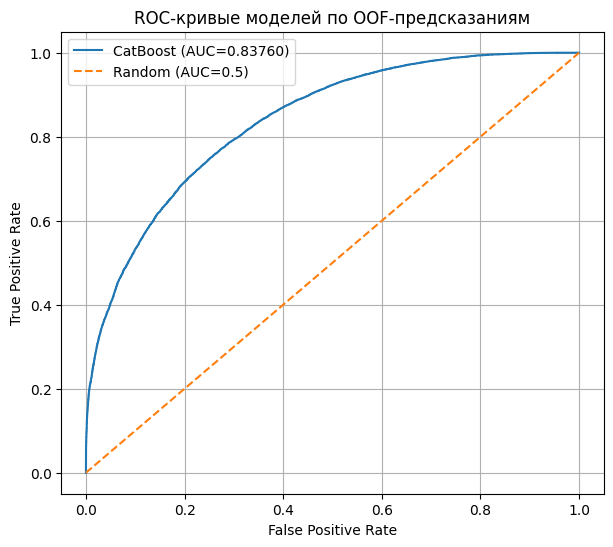

In [54]:

def plot_roc_curves_from_oof(y, oof_dict):
    """
    oof_dict: {"Model name": oof_pred_array}
    """
    y_true = y.astype(int)

    plt.figure(figsize=(7, 6))

    for name, pred in oof_dict.items():
        fpr, tpr, _ = roc_curve(y_true, pred)
        auc = roc_auc_score(y_true, pred)
        plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.5f})")

    # линия случайного угадывания
    plt.plot([0, 1], [0, 1], linestyle="--", label="Random (AUC=0.5)")

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC-кривые моделей по OOF-предсказаниям")
    plt.legend()
    plt.grid(True)
    plt.show()


plot_roc_curves_from_oof(
    y,
    {
        "CatBoost": results_cb["oof_pred"],
    }
)


### 7.4 Выводы по валидации

Все рассмотренные модели демонстрируют качество выше базового уровня случайного угадывания. 
Наиболее высокий ROC-AUC показывает модель CatBoost, что ожидаемо для табличных данных с большим количеством статистических признаков игроков. 
Logistic Regression даёт стабильный и интерпретируемый бейзлайн, а RandomForest позволяет учесть нелинейные взаимодействия, но уступает градиентному бустингу по итоговому ROC-AUC.


# 8. Интерпретация модели и важность признаков

После сравнения моделей я использую CatBoost как основную модель и провожу интерпретацию признаков. 
Цель этой секции - понять, какие игровые факторы на данном таймстемпе сильнее всего связаны с вероятностью победы Radiant.


In [55]:
cb_model = CatBoostClassifier(**best_params)
cb_model.fit(X.drop(columns=hero_cols, errors="ignore"), y, verbose=0)

# Важность
fi = cb_model.get_feature_importance()
fi_df = pd.DataFrame({
    "feature": X.drop(columns=hero_cols, errors="ignore").columns,
    "importance": fi
}).sort_values("importance", ascending=False)

fi_df.head(10)


,feature,importance
267,radiant_gold_advantage,7.637583
308,radiant_hero_winrate_advantage,2.957166
288,radiant_xp_advantage,2.002884
285,radiant_level_advantage,1.466132
256,r2_hero_winrate,1.082747
259,r5_hero_winrate,0.897006
125,d1_hero_id,0.883084
306,radiant_total_hero_winrate,0.854063
149,d2_hero_id,0.851507
292,radiant_hero_damage_advantage,0.849409


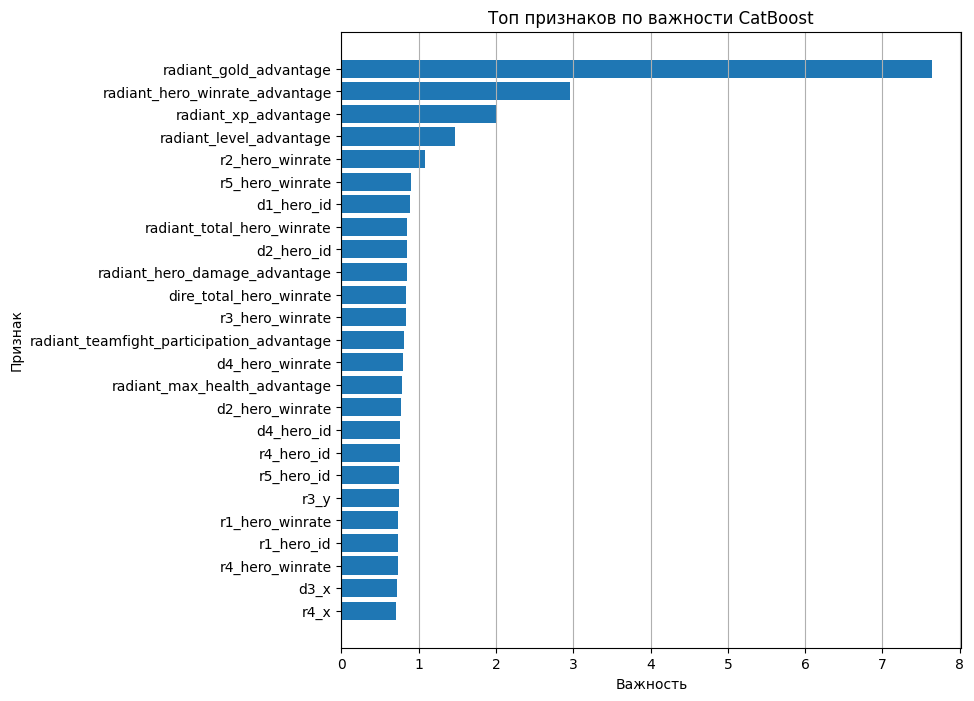

In [56]:
top_n = 25
fi_top = fi_df.head(top_n).sort_values("importance")

plt.figure(figsize=(8, 8))
plt.barh(fi_top["feature"], fi_top["importance"])
plt.title("Топ признаков по важности CatBoost")
plt.xlabel("Важность")
plt.ylabel("Признак")
plt.grid(True, axis="x")
plt.show()


### 8.1 Предметная интерпретация результатов важности

В топе важности ожидаемо доминируют признаки преимущества Radiant над Dire. Это подтверждает, что модель опирается на игровые факторы, напрямую связанные с вероятностью победы, а не на случайные артефакты.

Ключевые наблюдения по списку важных признаков:

1) **Экономика как главный сигнал**
На первом месте находится `radiant_gold_advantage`. Это логично, так как преимущество по золоту отражает более быстрый выход в ключевые предметы, доступ к силовым пикам и контроль темпа игры.

2) **Сильный вклад состава команд**
Высокие позиции занимают:
- `radiant_hero_winrate_advantage`
- `radiant_total_hero_winrate`
- `dire_total_hero_winrate`
- слотовые `r?_hero_winrate`

Это означает, что модель системно учитывает качество пика. При этом важно, что hero winrate признаки рассчитывались внутри фолдов, поэтому модель получает честную оценку силы героев без утечки таргета.

3) **Темп развития подтверждает выводы экономики**
В топе присутствуют:
- `radiant_xp_advantage`
- `radiant_level_advantage`

Это взаимодополняющие метрики, отражающие преимущество по ресурсу и уровневые пики, особенно важные на ранних и средних таймингах.

4) **Боевая эффективность и контроль карты**
Признаки вроде `radiant_teamfight_participation_advantage` и `radiant_hero_damage_advantage` показывают, что модель учитывает не только накопленные ресурсы, но и реализацию преимущества через драки.

5) **Сырые идентификаторы героев тоже дают сигнал**
В топе встречаются `d1_hero_id`, `d2_hero_id`, `d4_hero_id`, `r?_hero_id`. 
Это нормальное поведение для бустинга. Даже при наличии winrate-энкодинга конкретные герои могут давать дополнительную информацию о синергиях и матчапах, которые агрегированный winrate отражает не полностью.

### 8.2 Вывод по интерпретации

Список наиболее важных признаков хорошо согласуется с игровой логикой Dota 2. 
Модель в первую очередь опирается на преимущество по экономике и темпу, а также на качество пика героев, дополнительно учитывая показатели боевой реализации преимущества. 
Это подтверждает корректность feature engineering и повышает доверие к итоговым предсказаниям модели.


# 9. Анализ ошибок и предложения по улучшению

В этой секции я разбираю, где модель ошибается, и формулирую конкретные направления улучшения. 
Цель не только перечислить идеи, но и приоритизировать их с учетом потенциального влияния на ROC-AUC и сложности реализации.

В качестве основы для анализа ошибок я использую OOF-предсказания CatBoost. 
Это позволяет рассматривать ошибки на валидации без смещения оценки качества.

---

### 9.1 Где модель ошибается

Интуитивно сложнее всего предсказывать исход матчей в ситуациях, где:
- преимущества команд по экономике и опыту минимальны
- игра находится на раннем тайминге, когда один успешный тимфайт может резко изменить ситуацию
- составы команд обладают нестандартными синергиями, которые не полностью отражаются в агрегатах и hero winrate

Практически это означает, что наибольшее число ошибок ожидаемо возникает в матчах с близкими значениями:
- `radiant_gold_advantage`
- `radiant_xp_advantage`
- `radiant_level_advantage`
- `radiant_hero_winrate_advantage`

---

### 9.2 Примеры наиболее уверенных ошибок

Ниже я вывожу несколько примеров матчей, где модель была уверена, но предсказала неверный исход. 
Это полезно для понимания, какие игровые сценарии недостаточно хорошо описаны текущими признаками.




In [57]:
oof_pred = results_cb["oof_pred"]
y_true = y.astype(int).reset_index(drop=True)

err_df = X.copy()
err_df = err_df.reset_index(drop=True)
err_df["y_true"] = y_true
err_df["y_pred"] = oof_pred
err_df["abs_error"] = np.abs(err_df["y_pred"] - err_df["y_true"])


conf_wrong = err_df[
    ((err_df["y_pred"] >= 0.8) & (err_df["y_true"] == 0)) |
    ((err_df["y_pred"] <= 0.2) & (err_df["y_true"] == 1))
].sort_values("abs_error", ascending=False)

cols_to_show = [
    c for c in [
        "match_id_hash",
        "game_time",
        "radiant_gold_advantage",
        "radiant_xp_advantage",
        "radiant_level_advantage",
        "radiant_hero_winrate_advantage",
        "radiant_total_hero_winrate",
        "dire_total_hero_winrate",
        "y_true",
        "y_pred"
    ]
    if c in conf_wrong.columns
]

conf_wrong[cols_to_show].head(10)


,game_time,radiant_gold_advantage,radiant_xp_advantage,radiant_level_advantage,radiant_hero_winrate_advantage,radiant_total_hero_winrate,dire_total_hero_winrate,y_true,y_pred
13116,993,27868,43708,33,0.130265,2.515656,2.385391,0,0.991674
8562,2162,16317,16942,13,0.128015,2.590194,2.462179,0,0.991084
12078,662,16197,20252,20,0.116762,2.553976,2.437215,0,0.987307
21515,800,33094,21670,10,0.011719,2.493924,2.482206,0,0.980480
28007,1654,-13530,-17348,-12,-0.075985,2.405549,2.481534,1,0.020175
38546,684,-25810,-15837,-12,-0.174966,2.359663,2.534629,1,0.022242
489,1512,-10283,-17904,-13,-0.224368,2.290954,2.515322,1,0.023747
33842,1675,-14665,-16937,-13,0.005986,2.521435,2.515450,1,0.023803
30659,1869,-10384,-13226,-9,-0.050871,2.426171,2.477042,1,0.024519
5275,2185,14239,12971,10,-0.060754,2.484761,2.545515,0,0.974675


Так же можно вывести матчи где модель была не уверена.

In [58]:
borderline = err_df[(err_df["y_pred"] > 0.45) & (err_df["y_pred"] < 0.55)]
borderline[cols_to_show].head(10)


,game_time,radiant_gold_advantage,radiant_xp_advantage,radiant_level_advantage,radiant_hero_winrate_advantage,radiant_total_hero_winrate,dire_total_hero_winrate,y_true,y_pred
2,21,400,0,0,-0.074860,2.501499,2.576360,1,0.470957
5,160,1104,429,1,-0.129590,2.509961,2.639550,0,0.530869
14,721,928,1199,2,-0.073197,2.434696,2.507893,0,0.538132
24,342,-400,78,-1,0.031484,2.506075,2.474591,0,0.490633
26,1249,119,-2958,-5,0.073745,2.531521,2.457776,1,0.545070
27,907,824,564,1,-0.043707,2.503762,2.547470,1,0.540012
32,2991,-272,-1072,1,-0.091317,2.436055,2.527371,1,0.470963
34,79,633,-206,0,-0.077428,2.364976,2.442404,0,0.522040
41,876,179,1448,2,0.004172,2.486147,2.481975,0,0.532744
56,105,-377,-767,-3,0.075378,2.511114,2.435736,0,0.529717


### 9.3 Интерпретация ошибок

По структуре ошибок можно ожидать следующие причины:

1) **Недостаток временной динамики**
Основные признаки в `train_features.csv` описывают состояние на одном таймстемпе. 
Однако реальный исход часто зависит от темпа изменения преимущества. 
Без учета динамики модель может переоценивать статические преимущества.

2) **Неполное описание синергий героев**
Hero winrate дает полезный статистический сигнал, но не учитывает парные и командные комбинации. 
Поэтому нестандартные драфты могут приводить к ошибкам даже при схожих агрегатах ресурсов.


### 9.4 Предложения по улучшению 

#### 1. Улучшение признаков динамики

Если использовать сырые данные и временные ряды, можно добавить:
- slope и приросты `gold_t`, `xp_t`, `lh_t`, `dn_t` за последние 2-3 точки
- время выхода в ключевое преимущество по золоту
- ранний темп фарма и опыта по ролям

Это должно лучше отличать ситуации стабильного преимущества от временных всплесков.

#### 2. Модельные признаки взаимодействий героев

Возможные идеи:
- парные фичи по двум ключевым героям команды
- агрегаты по ролям, если получится выделить позиции
- "сила драфта" как сумма/среднее winrate с поправкой на синергию

Даже простые парные признаки могут дать прирост.


#### 3. Улучшение эксперимента и устойчивости

- увеличить количество фолдов
- провести ограниченный поиск гиперпараметров для RandomForest и Logistic Regression
- проверить влияние отбора признаков или регуляризации

---

### 9.5 Итоговый вывод по ошибкам

Модель показывает устойчивое качество и использует логичные игровые сигналы, 
но ошибки концентрируются в матчах с небольшими преимуществами и в сценариях, где важна динамика и синергии драфта. 
Наиболее перспективное направление улучшения это добавление признаков из временных рядов и расширение описания взаимодействий героев.


# 10. Оформление выводов и коммерческая/прикладная интерпретация

В этом проекте мы построили модель для предсказания вероятности победы Radiant на основе статистики игроков, матчевых параметров и дополнительных инженерных признаков. Основной фокус был на корректной предобработке, осмысленном feature engineering и честной оценке качества через кросс-валидацию.

### 10.1 Краткий пересказ проделанной работы

В ходе проекта мы:
- изучили структуру подготовленных и сырых данных
- провели первичный EDA и проверку качества данных
- сформировали базовые и агрегированные признаки команд
- обучили и сравнил три модели: Logistic Regression, RandomForest и CatBoost
- оценили качество по ROC-AUC и проанализировал важность признаков

### 10.2 Что означает полученный ROC-AUC

ROC-AUC показывает, насколько хорошо модель различает победы Radiant и Dire по вероятностям.  
Если значение существенно выше 0.5, модель уверенно лучше случайного угадывания и может использоваться для ранжирования матчей по вероятности победы.

С практической точки зрения это значит, что модель способна:
- давать качественную оценку текущего преимущества команды на выбранном временном срезе
- помогать в аналитике матчей и разборе решений
- быть основой для простых рекомендательных или визуализационных систем в контексте матч-аналитики

### 10.3 Ограничения исследования

При интерпретации результатов важно учитывать ограничения:
- признаки фиксируют состояние игры на определенном моменте времени и частично теряют динамику
- часть сырых данных представлена списками и логами, которые могут требовать более глубокой агрегации

### 10.4 Дальнейшие шаги

Наиболее перспективные направления улучшения:
- извлечение динамических признаков из временных рядов `gold_t`, `xp_t`, `lh_t`, `dn_t`
- расширение командных и парных признаков по взаимодействиям героев
- более детальная работа с логами событий
- дополнительный и более системный подбор гиперпараметров для всех трех моделей

